### C2C12 and RPE1

In [35]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean
import os
import sys, time,random

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

%matplotlib qt

save_folder = r"C:\Users\victo\OneDrive - BGU\C2C12_Trinish"




# Defect dynamics time lapse

In [ ]:
plist = glob.glob(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei\*.tif")
np.unique(np.array([p.split("_")[-2] for p in plist]))

array(['s1', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17',
       's18', 's19', 's20'], dtype='<U3')

## Make dataframe with all defects and save as csv

In [62]:
%matplotlib qt

experiment = "s11" 
# image_list = glob.glob(r"C:/Users/victo/Downloads/SB_lab/RPE1_C2C12_/Test001/*.tif")
image_list_all = glob.glob(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei\*" + experiment + "*.tif")
image_list_all = natsorted(image_list_all, key=lambda y: y.lower())
image_list = image_list_all[120:220:1]

img1 = cv2.imread(image_list[-1])[:,:,0]

ori, plushalf, minushalf = analyze_defects(img1, sigma=25)

fig, ax1 = plt.subplots(1,1,  figsize=(6,6))
extent = ax1.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
# ax1.axis('off')   

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img1)
ax1.imshow(255-img_clahe, cmap="gray")  

s = 25
# x = np.arange(0, img1.shape[1], s)
# y = np.arange(0, img1.shape[0], s)
y, x = np.mgrid[0:img1.shape[0], 0:img1.shape[1]]

ax1.quiver(x[::s,::s], y[::s,::s],
    np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], 
    headaxislength=0, headwidth=0, headlength=0, 
    color='k', scale=45, pivot='mid', alpha=.5, width=.003)

alpha_half, scale_half = .8, 35    
ax1.plot(plushalf['x'], plushalf['y'],'ro',markersize=6, alpha=alpha_half)
ax1.quiver(plushalf['x'], plushalf['y'], 
    np.cos(plushalf['ang1']), -np.sin(plushalf['ang1']), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

ax1.plot(minushalf['x'], minushalf['y'],'bo',markersize=6, alpha=alpha_half)
for j in range(3):
    ax1.quiver(minushalf['x'], minushalf['y'], 
        np.cos(minushalf['ang'+str(j+1)]), -np.sin(minushalf['ang'+str(j+1)]), 
        headaxislength=0, headwidth=0, headlength=0, color='b', scale=scale_half, alpha=alpha_half)
        
# os.makedirs(save_folder + "/Images", exist_ok=True)
# fig.savefig(save_folder + "/Images/director_and_defects_last.png")

# cent, box = (350,630), 300
# ax1.set_xlim(cent[0]-box, cent[0]+box)
# ax1.set_ylim(cent[1]+box, cent[1]-box)
# fig.savefig(save_folder + "/Images/director_and_defects_last_zoom.png")


In [1350]:
image_list[0],image_list[-1],

('C:\\Users\\victo\\My Drive\\Curie\\Trinish\\30_01_18_RPE1_C2C12_5x_phase_nuclei\\RPE1_Fucci_C2C12_5x_15min_phase_nuclei_w1Trans_s1_t151.TIF',
 'C:\\Users\\victo\\My Drive\\Curie\\Trinish\\30_01_18_RPE1_C2C12_5x_phase_nuclei\\RPE1_Fucci_C2C12_5x_15min_phase_nuclei_w1Trans_s1_t250.TIF')

In [120]:
minushalf_df = pd.DataFrame([])
plushalf_df = pd.DataFrame([])

PLOT = False

experiment = "s15" 
# image_list = glob.glob(r"C:/Users/victo/Downloads/SB_lab/RPE1_C2C12_/Test001/*.tif")
image_list_all = glob.glob(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei\*" + experiment + "*.tif")
image_list_all = natsorted(image_list_all, key=lambda y: y.lower())
image_list = image_list_all[100:200:1]

if PLOT:
    fig, ax = plt.subplots(1,1, figsize=(10,10))
    ax.set_axis_off()
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())

    # u = np.zeros_like(cv2.imread(image_list[0])[:,:,0], dtype=np.float32)
    # v = np.zeros_like(u)

for (im_num,im1), im2 in zip(enumerate(image_list[:-1]), image_list[1:]):
    # print(os.path.basename(im1))
    img1 = cv2.imread(im1)[:,:,0]
    
    # calculate velocity and plot fields
    if PLOT:
        ax.clear()
        img2 = cv2.imread(im2)[:,:,0]
        flow = cv2.calcOpticalFlowFarneback(img1,img2, None, 0.5, 3, 
            winsize=15, iterations=3, poly_n=5, poly_sigma=1.2, flags=0)  
        # >> uncomment to have average flow representation
        # >>  TO DO devide by number of frames
        # u += flow[..., 0]
        # v += flow[..., 1]
        # flow = np.stack((u, v), axis=-1)

        divergence = gaussian_filter(divergence_npgrad(flow), sigma=25)

        # Apply Contrast Limited Adaptive Histogram Equalization
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img_clahe = clahe.apply(img1)
        ax.imshow(255-img_clahe, "gray")
        ax.imshow(divergence, "jet", alpha=.3, vmin=-0.03, vmax=0.03)

    ori, plushalf, minushalf = analyze_defects(img1, sigma=21)
    frame_num = int(os.path.splitext(os.path.basename(im1))[0].split("_t")[-1])
    minushalf['frame'] = frame_num
    plushalf['frame'] = frame_num
    minushalf_df = pd.concat([minushalf_df, minushalf], ignore_index=True)
    plushalf_df = pd.concat([plushalf_df, plushalf], ignore_index=True)
    
    if PLOT:
        alpha_half, scale_half = .9, 40    
        ax.plot(plushalf['x'], plushalf['y'],'ro',markersize=6, alpha=1)
        ax.quiver(plushalf['x'], plushalf['y'], 
            np.cos(plushalf['ang1']), -np.sin(plushalf['ang1']), 
            headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

        ax.plot(minushalf['x'], minushalf['y'],'bo',markersize=6, alpha=1)
        for i in range(3):
            ax.quiver(minushalf['x'], minushalf['y'], 
                np.cos(minushalf['ang'+str(i+1)]), -np.sin(minushalf['ang'+str(i+1)]), 
                headaxislength=0, headwidth=0, headlength=0, color='b', scale=scale_half, alpha=alpha_half)
    
    
        save_path = os.path.join(
            r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_", 
            experiment,
            'Nematic', 
            os.path.splitext(os.path.basename(im1))[0]
            )
    
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, bbox_inches=extent.expanded(1.15, 1.15))
    # break 
    progressBar(im_num, len(image_list))   

os.makedirs(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment , exist_ok=True)
minushalf_df.to_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/MinusHalf1.csv")
plushalf_df.to_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusHalf1.csv")

In [52]:
os.makedirs(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment , exist_ok=True)
minushalf_df.to_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/MinusHalf1.csv")
plushalf_df.to_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusHalf1.csv")

In [ ]:
minushalf_df.frame.min(), minushalf_df.frame.max()

(121, 219)

## Topological charge dynamis (number of defects)

In [ ]:
%matplotlib inline

fig = plt.figure(figsize=(9,4))
ax1 = plt.subplot(121)

# ax2 = ax1.twinx()
charge = []
for experiment in ["s1", "s10","s11"]:
    minushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/MinusHalf1.csv')
    plushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/PlusHalf1.csv')

    frames = minushalf_df.frame.unique()
    charge_p = [plushalf_df.charge[(plushalf_df.frame==frame)].sum() for frame in minushalf_df.frame.unique()]
    charge_n = [minushalf_df.charge[(minushalf_df.frame==frame)].sum() for frame in minushalf_df.frame.unique()]

    charge.append(pd.DataFrame({
        "frame": frames,
        "plus": np.array(charge_p),
        "minus": np.array(charge_n),
                         }))
charge_df = pd.concat(charge)
charge_df["total"] = charge_df.plus + charge_df.minus

show = False
for color,defect_type in zip(["r","b"],["plus","minus"]):
    df = plot_rolling_average(charge_df, ax1, defect_type, "frame",show=show,color=color, avfunc=np.mean, stdfunc=np.std)
    if not show:
        ax1.plot((1/4)*(df.frame-df.frame.iloc[0]), df[defect_type+"_ave"], alpha=.6, linewidth=3, color=color, label=defect_type)
        ax1.fill_between((1/4)*(df.frame-df.frame.iloc[0]), df[defect_type+"_ave"]-df[defect_type+"_std"], df[defect_type+"_ave"]+df[defect_type+"_std"],
                        alpha=.2,color=color)
    # break

ax1.set_xlabel(r"$Time ~(hr)$", fontsize=14)
ax1.set_ylabel(r"$Topological ~Charge$", fontsize=14)
plt.legend(loc='best', fontsize=12)

ax2 = plt.subplot(122)
color, defect_type = "k","total"
df = plot_rolling_average(charge_df, ax1, defect_type, "frame",show=show,color=color, avfunc=np.mean, stdfunc=np.std)
if not show:
    ax2.plot((1/4)*(df.frame-df.frame.iloc[0]), df[defect_type+"_ave"], alpha=.6, linewidth=3,color=color, label=defect_type+" charge")
    ax2.fill_between((1/4)*(df.frame-df.frame.iloc[0]), df[defect_type+"_ave"]-df[defect_type+"_std"], df[defect_type+"_ave"]+df[defect_type+"_std"],
                    alpha=.2,color=color)
ax2.set_ylim([-5,5])
ax2.set_xlabel(r"$Time ~(hr)$", fontsize=14)
plt.legend(loc='best', fontsize=12)

In [53]:
experiment = "s10"
minushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/MinusHalf1.csv')
plushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/PlusHalf1.csv')

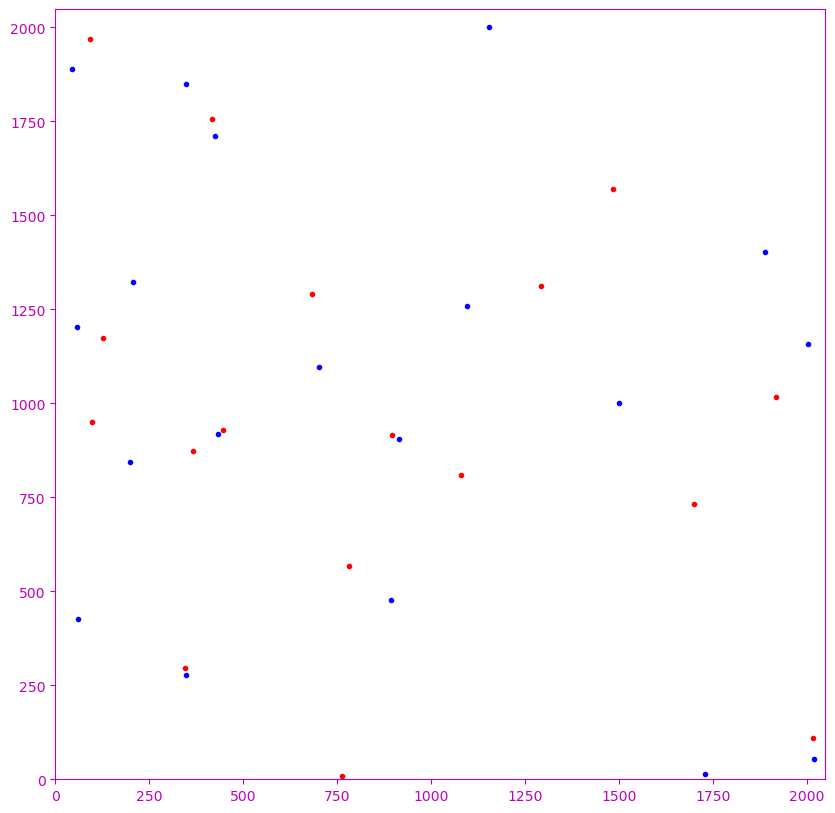

In [121]:
%matplotlib inline
import matplotlib
matplotlib.rc('axes', edgecolor='m')
plt.rcParams['xtick.color'] = 'm'
plt.rcParams['ytick.color'] = 'm'

frames = minushalf_df["frame"].unique()

fig, ax = plt.subplots(1,1, figsize=(10,10))
# ax.set_axis_off()
extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
# plt.tight_layout()
white_frame = np.ones((2048,2048,3))

for f in frames:
    
    minushalf = minushalf_df[minushalf_df["frame"]==f]
    plushalf = plushalf_df[plushalf_df["frame"]==f]
    
    alpha_half, scale_half = .9, 40   
    ax.clear() 
    # ax.imshow(white_frame, "gray")
    ax.plot(plushalf['x'], plushalf['y'],'r.',markersize=6, alpha=1)
    # ax.quiver(plushalf['x'], plushalf['y'], 
    #     np.cos(plushalf['ang1']), -np.sin(plushalf['ang1']), 
    #     headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

    ax.plot(minushalf['x'], minushalf['y'],'b.',markersize=6, alpha=1)
    # for i in range(3):
    #     ax.quiver(minushalf['x'], minushalf['y'], 
    #         np.cos(minushalf['ang'+str(i+1)]), -np.sin(minushalf['ang'+str(i+1)]), 
    #         headaxislength=0, headwidth=0, headlength=0, color='b', scale=scale_half, alpha=alpha_half)  

    save_path = os.path.join(
        r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_", 
        experiment,
        'Nematic2',
        'frame_' + str(f) + ".png"
        )
    # break
    ax.set_xlim([0, 2048])
    ax.set_ylim([0, 2048])
    plt.gca().set_box_aspect(1)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, bbox_inches=extent.expanded(1.15, 1.15))        

    # break

## Import CSVs

In [ ]:
first_frame, last_frame, experiment

(121, 219, 's11')

In [122]:
experiment = "s15" 

minushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/MinusHalf1.csv')
plushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment +'/PlusHalf1.csv')

minushalf_TM = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment +'/MinusTM_spots.csv', skiprows=[1,2,3])
plushalf_TM = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment +'/PlusTM_spots.csv', skiprows=[1,2,3])

first_frame = minushalf_df["frame"].min() # Validate this number in image folders
last_frame = minushalf_df["frame"].max() # Validate this number in image folders

print("  ////////    PLUS   //////////")
print([(plushalf_TM[plushalf_TM["FRAME"]==i]).shape for i in range(10)])
print([(plushalf_df[plushalf_df["frame"]==i+first_frame]).shape for i in range(10)])

print("\n ////////    MINUS   //////////")
print([(minushalf_TM[minushalf_TM["FRAME"]==i]).shape for i in range(10)])
print([(minushalf_df[minushalf_df["frame"]==i+first_frame]).shape for i in range(10)])

  ////////    PLUS   //////////
[(53, 20), (55, 20), (51, 20), (46, 20), (45, 20), (43, 20), (46, 20), (46, 20), (44, 20), (44, 20)]
[(54, 10), (55, 10), (51, 10), (46, 10), (45, 10), (43, 10), (46, 10), (46, 10), (44, 10), (44, 10)]

 ////////    MINUS   //////////
[(51, 20), (54, 20), (49, 20), (44, 20), (43, 20), (41, 20), (45, 20), (44, 20), (41, 20), (40, 20)]
[(51, 10), (54, 10), (49, 10), (44, 10), (43, 10), (41, 10), (45, 10), (44, 10), (41, 10), (40, 10)]


## Find shift and rescale

slope: 2.6594134032260133 | intercept: -161.01086051216691
slope: 2.6594134032260133 | intercept: -161.01086051216691
slope: 2.6590517407966954 | intercept: -160.85992107889228
-------  X  ------------
slope: 2.6584709724700977 | intercept: -151.6552621894716
slope: 2.6584709724700977 | intercept: -151.6552621894716
slope: 2.658892382946148 | intercept: -151.6255082517438
-------  Y  ------------


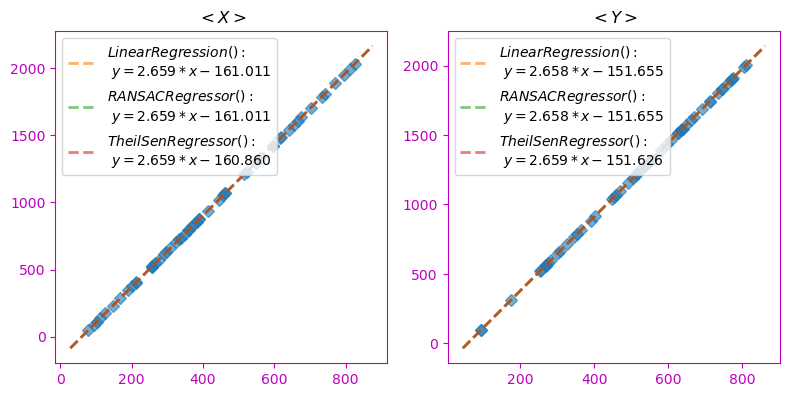

In [123]:
from sklearn import linear_model

%matplotlib inline
frame = 1

fig, axs = plt.subplots(1,2,  figsize=(8,16))

dims = ("x", "y")
lrs = (
    linear_model.LinearRegression(), 
    linear_model.RANSACRegressor(), 
    linear_model.TheilSenRegressor()
    )

slope_intercept = {}

for ax,dd in zip(axs, dims):
    ave_slope, ave_intercept = 0, 0

    X = plushalf_TM["POSITION_"+dd.upper()][plushalf_TM["FRAME"]==frame].iloc[:].sort_values().values
    y = plushalf_df[dd][plushalf_df["frame"]==first_frame+frame].iloc[:]

    if dd=="y":
        # !!! insert image height (e.g. 2048)
        y = (2048 - y) # y- values are flipped
    y = y.sort_values().values

    ax.plot(X, y, "D", alpha=.6)

    for lr in lrs:
        lr.fit(X.reshape(-1, 1), y)
        try:
            slope = lr.estimator_.coef_[0]
            intercept = lr.estimator_.intercept_
        except:
            slope = lr.coef_[0]
            intercept = lr.intercept_

        # use prints to set the SLOPE and INTERCEP globals in the next cell
        print('slope:', slope, '| intercept:', intercept)

        # prdict for line
        line_X = np.arange(X.min()-50, X.max()+50)[:, np.newaxis]
        line_y = lr.predict(line_X)

        ax.plot(line_X, line_y, "--", linewidth=2, alpha=.6,
                label="$%s:$\n $y= %.3f *x %.3f$" %(lr, slope, intercept))   
         
        ave_slope += slope  
        ave_intercept += intercept

    ax.set_title("$< %s >$" %dd.upper())

    ax.set_box_aspect(1)
    ax.legend(loc='upper left')
    print("-------  %s  ------------" %dd.upper())

    slope_intercept[dd] = {"slope": ave_slope/len(lrs),
                             "intercept": ave_intercept/len(lrs)
                             }

    # ave_slope = ave_slope/len(lrs)
    # ave_intercept = ave_intercept/len(lrs)
plt.tight_layout()

### Validate shift and rescale

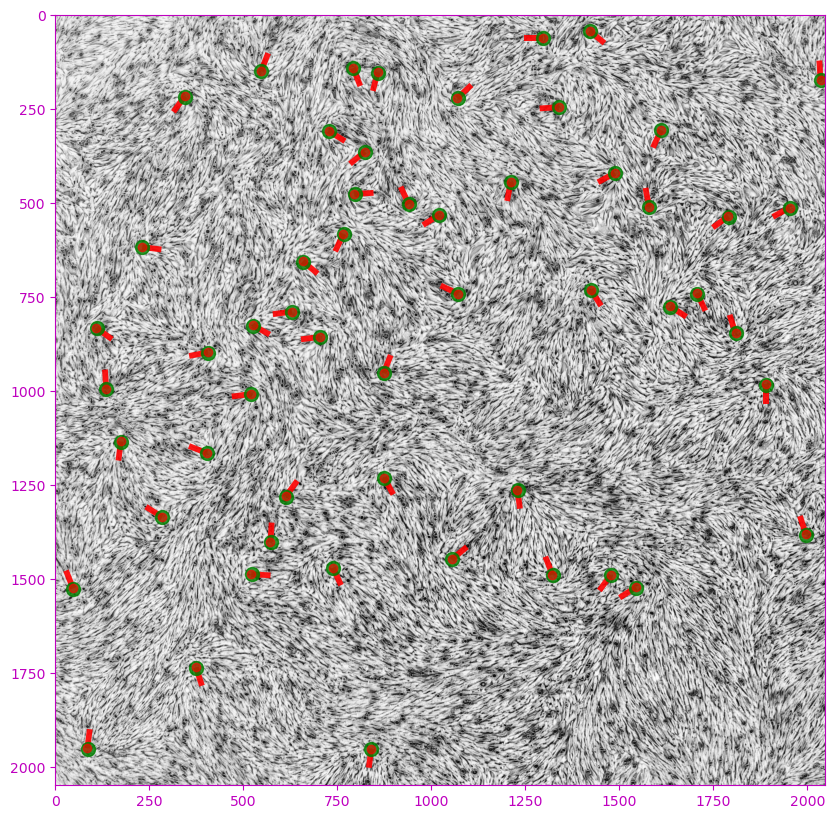

In [124]:
%matplotlib inline
SLOPEx = slope_intercept["x"]["slope"]
INTERCEPTx = slope_intercept["x"]["intercept"]
SLOPEy = slope_intercept["y"]["slope"]
INTERCEPTy = slope_intercept["y"]["intercept"]
frame = 1

image_list_all = glob.glob(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei\*" + experiment + "*.tif")
image_list_all = natsorted(image_list_all, key=lambda y: y.lower())
image_list = image_list_all[first_frame-1:last_frame-1:1]
im1 = image_list[0]

plushalf_TM = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/PlusTM_spots.csv', skiprows=[1,2,3])
plushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/PlusHalf1.csv')

# Apply Contrast Limited Adaptive Histogram Equalization
img1 = cv2.imread(im1)[:,:,0]
h_img, w_img = img1.shape
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img1)

fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.imshow(255-img_clahe, "gray")

x = plushalf_TM["POSITION_X"][plushalf_TM["FRAME"]==frame].iloc[:].values * SLOPEx + INTERCEPTx
y = h_img - (plushalf_TM["POSITION_Y"][plushalf_TM["FRAME"]==frame].iloc[:].values * SLOPEy + INTERCEPTy)
ax.plot(x, y,'go',markersize=10, alpha=.8)

alpha_half, scale_half = .9, 40  
p_df =  plushalf_df[plushalf_df["frame"]==first_frame+frame]
ax.plot(p_df['x'], p_df['y'],'ro',markersize=6, alpha=.6)
ax.quiver(p_df['x'], p_df['y'], 
    np.cos(p_df['ang1']), -np.sin(p_df['ang1']), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

### Apply angle information data to TrackMate DataFrame

In [125]:
%matplotlib qt
# SLOPEx = 2.2020369696888773
# INTERCEPTx = -153.5892752236614
# SLOPEy = 2.589611169431241
# INTERCEPTy = -152.43827493084723

# experiment = "s10" 

minushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/MinusHalf1.csv')
plushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment +'/PlusHalf1.csv')

minushalf_TM = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment +'/MinusTM_spots.csv', skiprows=[1,2,3])
plushalf_TM = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment +'/PlusTM_spots.csv', skiprows=[1,2,3])

first_frame = minushalf_df["frame"].min() # Validate this number in image folders

plushalf_TM["x_img"] = plushalf_TM["POSITION_X"] * SLOPEx + INTERCEPTx
plushalf_TM["y_img"] = h_img - (plushalf_TM["POSITION_Y"] * SLOPEy + INTERCEPTy)
minushalf_TM["x_img"] = minushalf_TM["POSITION_X"] * SLOPEx + INTERCEPTx
minushalf_TM["y_img"] = h_img - (minushalf_TM["POSITION_Y"] * SLOPEy + INTERCEPTy)

In [126]:
# find same dots and check
dfs_TM = [plushalf_TM, minushalf_TM]
dfs_ori = [plushalf_df, minushalf_df]

for df_TM, df_ori in zip(dfs_TM, dfs_ori):
    xy_ori = np.array([df_ori["x"], df_ori["y"]]).T
    xy_TM = np.array([df_TM["x_img"].values, df_TM["y_img"].values]).T
    _,idx = center_pairs(
        xy_ori, #Long Array
        xy_TM #Short Array
        ) 
    # break
    print(xy_ori[idx[100:103]],'\n', xy_TM[100:103],'\n', df_ori[['x', 'y']].loc[idx[100:103]].values)
    print("--------------")


    # replace and add angles
    df_TM[['x_img1','y_img1','ang1','ang2','ang3','charge']] =  df_ori[['x', 'y','ang1','ang2','ang3','charge']].iloc[idx[:]].values


[[ 520. 1007.]
 [ 174. 1133.]
 [ 403. 1164.]] 
 [[ 519.81461798 1005.93261003]
 [ 174.10654708 1133.54595978]
 [ 402.8057316  1162.79068463]] 
 [[ 520. 1007.]
 [ 174. 1133.]
 [ 403. 1164.]]
--------------
[[1313.   42.]
 [1043.  167.]
 [  26.  164.]] 
 [[1312.283887     43.5152678 ]
 [1043.69530924  168.47000509]
 [  25.19096749  163.15278374]] 
 [[1313.   42.]
 [1043.  167.]
 [  26.  164.]]
--------------


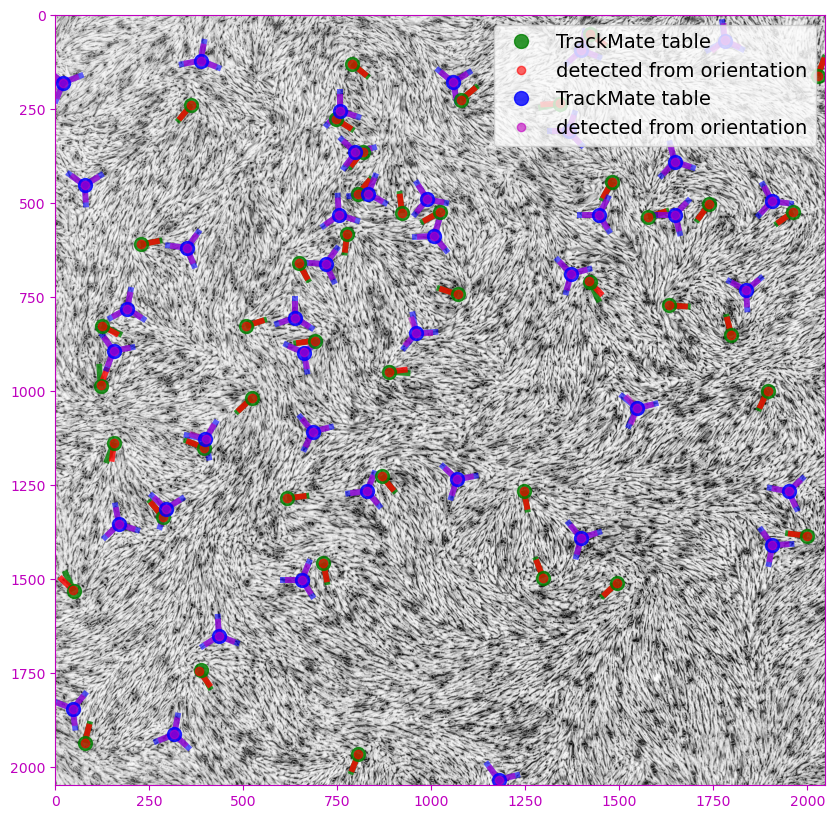

In [127]:
# test replaced values
%matplotlib inline
frame = 10

image_list_all = glob.glob(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei\*" + experiment + "*.tif")
image_list_all = natsorted(image_list_all, key=lambda y: y.lower())
image_list = image_list_all[first_frame-1:last_frame-1:1]
im1 = image_list[frame]

# Apply Contrast Limited Adaptive Histogram Equalization
img1 = cv2.imread(im1)[:,:,0]
h_img, w_img = img1.shape
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_clahe = clahe.apply(img1)

fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.imshow(255-img_clahe, "gray")

# +1/2
idx = plushalf_TM["FRAME"]==frame
ax.plot(plushalf_TM["x_img1"][idx],
        plushalf_TM["y_img1"][idx],'go',
        markersize=10, alpha=.8, label="TrackMate table")
ax.quiver(plushalf_TM['x_img1'][idx], plushalf_TM['y_img1'][idx], 
    np.cos(plushalf_TM['ang1'][idx]), -np.sin(plushalf_TM['ang1'][idx]), 
    headaxislength=0, headwidth=0, headlength=0, color='g', scale=35, alpha=.8)        

p_df =  plushalf_df[plushalf_df["frame"]==first_frame+frame]
ax.plot(p_df['x'], p_df['y'],'ro',markersize=6, alpha=.6, label="detected from orientation")
ax.quiver(p_df['x'], p_df['y'], 
    np.cos(p_df['ang1']), -np.sin(p_df['ang1']), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=40, alpha=.8)

# -1/2
idx = minushalf_TM["FRAME"]==frame
ax.plot(minushalf_TM["x_img1"][idx],
        minushalf_TM["y_img1"][idx],'bo',
        markersize=10, alpha=.8, label="TrackMate table")
for i in range(3):
    ax.quiver(minushalf_TM["x_img1"][idx], minushalf_TM["y_img1"][idx], 
        np.cos(minushalf_TM['ang'+str(i+1)][idx]), -np.sin(minushalf_TM['ang'+str(i+1)][idx]), 
        headaxislength=0, headwidth=0, headlength=0, color='b', scale=35, alpha=.6)    

m_df =  minushalf_df[minushalf_df["frame"]==first_frame+frame]
ax.plot(m_df['x'], m_df['y'],'mo',markersize=6, alpha=.6, label="detected from orientation")
for i in range(3):
    ax.quiver(m_df["x"], m_df["y"], 
        np.cos(m_df['ang'+str(i+1)][idx]), -np.sin(m_df['ang'+str(i+1)][idx]), 
        headaxislength=0, headwidth=0, headlength=0, color='m', scale=45, alpha=.6)    

ax.legend(loc='upper right', fontsize=14)

In [128]:
# Join TrackMate tabels for +1/2 and -1/2
pd.concat([plushalf_TM, minushalf_TM]).to_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusAndMinusTM.csv")

# Start Here Find Pairs

In [1]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean, circstd
import os
import sys
import pandas as pd
pd.options.mode.chained_assignment = None
import seaborn as sns
import sys,time,random
import matplotlib
matplotlib.rc('axes', edgecolor='k')
plt.rcParams['xtick.color'] = 'k'
plt.rcParams['ytick.color'] = 'k'

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

experiment = "s11"
PAIR_DIST_THRESH = 40

plus_minus_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusAndMinusTM.csv")
plus_minus_df.head()

,Unnamed: 0,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,...,CONTRAST_CH1,SNR_CH1,x_img,y_img,x_img1,y_img1,ang1,ang2,ang3,charge
0,0,ID2226721,2226721,22.0,37.621490,794.0,657.0,0.0,0.0,0,...,1.0,0.890634,1950.700547,452.684893,1951.0,453.0,1.633628,NaN,NaN,0.5
1,1,ID2226720,2226720,23.0,37.621494,607.0,632.0,0.0,0.0,0,...,1.0,0.890634,1453.321089,519.191218,1452.0,519.0,0.314159,NaN,NaN,0.5
2,2,ID2226723,2226723,28.0,37.621490,354.0,686.0,0.0,0.0,0,...,1.0,0.890634,780.395939,375.537555,780.0,375.0,-0.942478,NaN,NaN,0.5
3,3,ID2226722,2226722,25.0,37.621490,704.0,665.0,0.0,0.0,0,...,1.0,0.890634,1711.320059,431.402868,1710.0,432.0,0.753982,NaN,NaN,0.5
4,4,ID2226725,2226725,NaN,37.571358,423.0,698.0,0.0,0.0,0,...,1.0,0.886791,963.920980,343.614519,963.0,344.0,2.136283,NaN,NaN,0.5


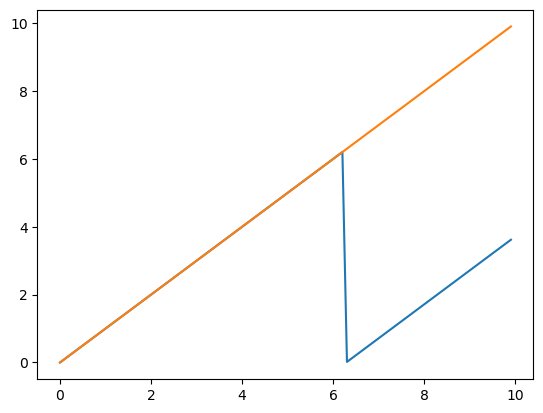

In [2]:
ang = np.arange(0,10,.1)
mod_ang = ang % (2*np.pi)
plt.plot(ang, mod_ang)
plt.plot(ang, np.unwrap(mod_ang, period=(2*np.pi)))

(15001, 29)

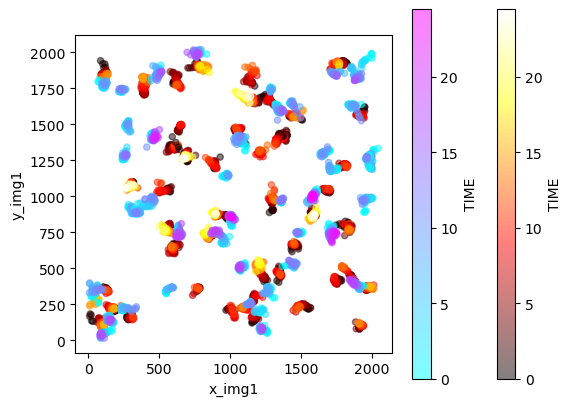

In [3]:
%matplotlib inline
experiment = "s1"
plus_minus_df_ = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusAndMinusTM.csv").dropna(subset=['TRACK_ID'])
plus_minus_df_["TIME"] = 1/4 * plus_minus_df_["FRAME"]

plus_df_ = plus_minus_df_[plus_minus_df_.charge==.5].copy()
minus_df_ = plus_minus_df_[plus_minus_df_.charge==-.5].copy()

minimal_track = 35
plus_df = plus_df_.groupby('TRACK_ID').filter(lambda x : len(x)>minimal_track).copy()
minus_df = minus_df_.groupby('TRACK_ID').filter(lambda x : len(x)>minimal_track).copy()

plus_df.TIME = plus_df.groupby(['TRACK_ID'])['TIME'].transform(lambda x: x-x.iloc[0])
minus_df.TIME = minus_df.groupby(['TRACK_ID'])['TIME'].transform(lambda x: x-x.iloc[0])

fig, ax1 = plt.subplots(1,1)
plus_df.plot.scatter("x_img1","y_img1", ax=ax1, c="TIME", alpha=.5, cmap='hot')
minus_df.plot.scatter("x_img1","y_img1", ax=ax1, c="TIME", alpha=.5, cmap='cool')

plt.gca().set_box_aspect(1)
plus_minus_df.shape

## Number of Defects over time

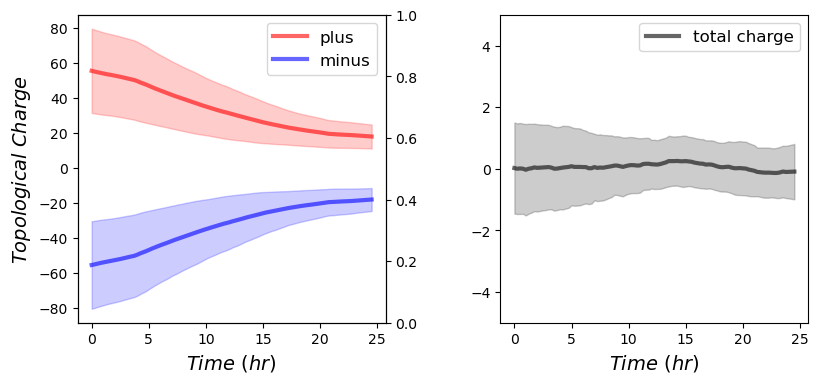

In [46]:
%matplotlib inline

fig = plt.figure(figsize=(10,4))
ax1 = plt.subplot(121)

ax3 = ax1.twinx()
charge = []
# for experiment in ["s1", "s10","s11","s12"]:
for experiment in ["s19", "s15","s14"]:
    plus_minus_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusAndMinusTM.csv").dropna(subset=['TRACK_ID'])

    frames = plus_minus_df.FRAME.unique()
    charge_p = np.array([plus_minus_df.charge[(plus_minus_df.charge==.5)&(plus_minus_df.FRAME==frame)].sum() for frame in plus_minus_df.FRAME.unique()])
    charge_n = np.array([plus_minus_df.charge[(plus_minus_df.charge==-.5)&(plus_minus_df.FRAME==frame)].sum() for frame in plus_minus_df.FRAME.unique()])

    charge.append(pd.DataFrame({
        "frame": frames,
        "plus": charge_p,#/(charge_p[0]),
        "minus": charge_n,#/-(charge_n[0]),
                         }))
    
charge_df = pd.concat(charge)
charge_df["total"] = charge_df.plus + charge_df.minus

show = False
lns = []
for ax,color,defect_type in zip([ax1,ax1],["r","b"],["plus","minus"]):
    df = plot_rolling_average(charge_df, ax, defect_type, "frame",show=show,color=color, avfunc=np.mean, stdfunc=np.std)
    if not show:
        ax.plot((1/4)*(df.frame-df.frame.iloc[0]), df[defect_type+"_ave"], alpha=.6, linewidth=3, color=color, label=defect_type)
        ax.fill_between((1/4)*(df.frame-df.frame.iloc[0]), df[defect_type+"_ave"]-df[defect_type+"_std"], df[defect_type+"_ave"]+df[defect_type+"_std"],
                        alpha=.2,color=color)
        ax.set_box_aspect(1)
        
    # break
# ask matplotlib for the plotted objects and their labels
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=12)

ax1.set_xlabel(r"$Time ~(hr)$", fontsize=14)
ax1.set_ylabel(r"$Topological ~Charge$", fontsize=14)


ax2 = plt.subplot(122)
color, defect_type = "k","total"
df = plot_rolling_average(charge_df, ax1, defect_type, "frame",show=show,color=color, avfunc=np.mean, stdfunc=np.std)
if not show:
    ax2.plot((1/4)*(df.frame-df.frame.iloc[0]), df[defect_type+"_ave"], alpha=.6, linewidth=3,color=color, label=defect_type+" charge")
    ax2.fill_between((1/4)*(df.frame-df.frame.iloc[0]), df[defect_type+"_ave"]-df[defect_type+"_std"], df[defect_type+"_ave"]+df[defect_type+"_std"],
                    alpha=.2,color=color)
ax2.set_ylim([-5,5])
ax2.set_xlabel(r"$Time ~(hr)$", fontsize=14)
ax2.set_box_aspect(1)
plt.legend(loc='best', fontsize=12)

Text(0.5, 1.0, '$Number ~of ~\\pm 1/2 ~defects$$~(EXP: ~s11)$')

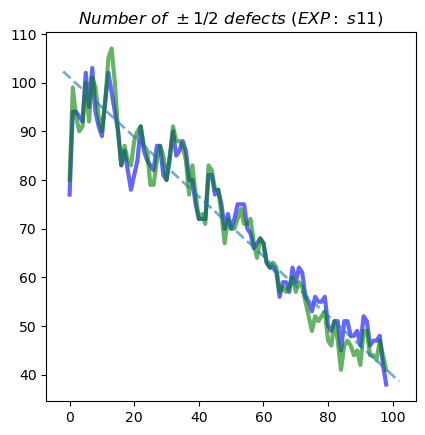

In [5]:
experiment = "s11"

plus_minus_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusAndMinusTM.csv").dropna(subset=['TRACK_ID'])

charge_av = []
charge_std = []
charge_p = []
charge_n = []
for frame in plus_minus_df.FRAME.unique():
    # charge_av.append(plus_minus_df.charge[plus_minus_df.FRAME==frame].sum())
    # charge_std.append(plus_minus_df.charge[plus_minus_df.FRAME==frame].std())
    charge_p.append(plus_minus_df.charge[(plus_minus_df.charge==.5)&(plus_minus_df.FRAME==frame)].sum())
    charge_n.append(plus_minus_df.charge[~(plus_minus_df.charge==.5)&(plus_minus_df.FRAME==frame)].sum())

charge_av = np.array(charge_av)
charge_std = np.array(charge_std)
# plt.plot(plus_minus_df.FRAME.unique(), charge_av, "o")
# plt.fill_between(plus_minus_df.FRAME.unique(), 
#                 charge_av - charge_std, 
#                 charge_av + charge_std, 
#                 color=color, alpha=.2) 
plt.plot(plus_minus_df.FRAME.unique(), 2*np.abs(charge_n), "-b", alpha=.6, linewidth=3)
plt.plot(plus_minus_df.FRAME.unique(), 2*np.array(charge_p), "-g", alpha=.6, linewidth=3)

plt.gca().set_box_aspect(1)


from sklearn import linear_model
lr = linear_model.TheilSenRegressor()
X = np.array(plus_minus_df.FRAME.unique()).reshape(-1, 1)
y = 2*np.array(charge_p)

lr.fit(X, y)
line_X = np.arange(X.min()-2, X.max()+5)[:, np.newaxis]
line_y = lr.predict(line_X)
plt.plot(line_X, line_y, "--", linewidth=2, alpha=.6)   
plt.title(r"$Number ~of ~\pm 1/2 ~defects$" + r"$~(EXP: ~%s)$" % experiment)
        

19000369.0
15000101.0
14000438.0


Text(0.5, 1.0, "['s19', 's15', 's14']")

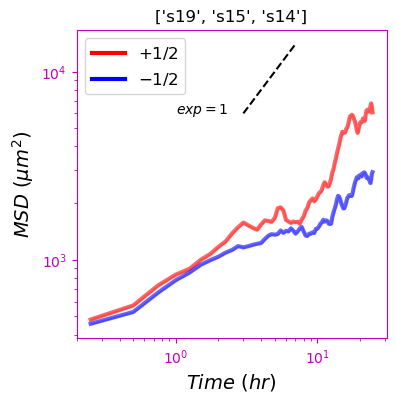

In [130]:
%matplotlib inline
fig, ax2 = plt.subplots(1,1, figsize=(4,4))
# msd_plus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="b", alpha=.05)
# msd_minus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="g", alpha=.05)

plus_minus_df = []

# experiments = ["s1", "s10","s11","s12"]
experiments = ["s19", "s15","s14"]

for experiment in experiments:
    df_temp = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusAndMinusTM.csv").dropna(subset=['TRACK_ID'])
    df_temp.TRACK_ID += (int(experiment.replace('s', ''))*1e6) # add expriment number as number of millions [1e6, 10e6, 11e6]
    df_temp["TIME"] = 1/4 * df_temp["FRAME"]

    plus_minus_df.append(
        df_temp
    )
    print(plus_minus_df[-1].TRACK_ID.max())

plus_minus_df_ = pd.concat(plus_minus_df)

plus_df_ = plus_minus_df_[plus_minus_df_.charge==.5].copy()
minus_df_ = plus_minus_df_[plus_minus_df_.charge==-.5].copy()

minimal_track = 5
plus_df = plus_df_.groupby('TRACK_ID').filter(lambda x : len(x)>minimal_track).copy()
minus_df = minus_df_.groupby('TRACK_ID').filter(lambda x : len(x)>minimal_track).copy()

msd_plus_df = msd_from_df(plus_df,"x_img1","x_img1","TIME","TRACK_ID")
msd_minus_df = msd_from_df(minus_df,"x_img1","x_img1","TIME","TRACK_ID")

win = 1/4

for msd_df,color in zip([msd_plus_df, msd_minus_df], ["r","b"]):

    msd_df = msd_df.sort_values(by="FRAME")
    msd_df.MSD *= 1.5 # convert micron to pixels
    msd_df["ave"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.mean)
    msd_df["std"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.std)
    msd_df["count"] = roll_func(msd_df.MSD, msd_df.FRAME, win, np.sum)

    ax2.plot(msd_df.FRAME, msd_df["ave"], "-", color=color, alpha=.6, linewidth=3)
    ax2.fill_between(msd_df.FRAME, 
                    msd_df["ave"]-msd_df["std"]/msd_df["count"]**.5, 
                    msd_df["ave"]+msd_df["std"]/msd_df["count"]**.5, 
                    color=color, alpha=.2) 


ax2.plot([0,0],[0,0], "-", color="r", linewidth=3, label=r"$+1/2$")
ax2.plot([0,0],[0,0], "-", color="b", linewidth=3, label=r"$-1/2$")
xref = np.arange(3, 8, 1)
ax2.plot(xref, 2e3*xref**1,"--k")
ax2.text(1, 2e3*xref[0]**1, r"$exp=1$")

ax2.set_xscale('log'); ax2.set_yscale('log')

ax2.set_xlabel(r"$Time ~(hr)$", fontsize=14)
ax2.set_ylabel(r"$MSD ~(\mu m^2)$", fontsize=14)

plt.legend(loc='upper left', fontsize=12)
plt.title(experiments)

Text(0.5, 1.0, '$MSD$$~(EXP: ~s11)$')

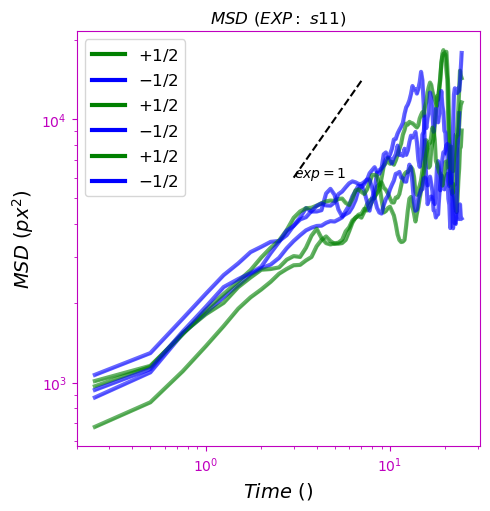

In [74]:
%matplotlib inline
fig, ax2 = plt.subplots(1,1, figsize=(5,5))
# msd_plus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="b", alpha=.05)
# msd_minus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="g", alpha=.05)

for experiment in ["s1", "s10","s11","s12"]:
# for experiment in ["s19", "s15","s14"]:
    plus_minus_df_ = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusAndMinusTM.csv").dropna(subset=['TRACK_ID'])
    plus_minus_df_["TIME"] = 1/4 * plus_minus_df_["FRAME"]

    plus_df_ = plus_minus_df_[plus_minus_df_.charge==.5].copy()
    minus_df_ = plus_minus_df_[plus_minus_df_.charge==-.5].copy()

    minimal_track = 5
    plus_df = plus_df_.groupby('TRACK_ID').filter(lambda x : len(x)>minimal_track).copy()
    minus_df = minus_df_.groupby('TRACK_ID').filter(lambda x : len(x)>minimal_track).copy()

    msd_plus_df = msd_from_df(plus_df,"x_img1","x_img1","TIME","TRACK_ID")
    msd_minus_df = msd_from_df(minus_df,"x_img1","x_img1","TIME","TRACK_ID")

    win = 1/4

    for msd_df,color in zip([msd_plus_df, msd_minus_df], ["g","b"]):

        msd_df = msd_df.sort_values(by="FRAME")
        msd_df.MSD *= 1.5 # convert micron to pixels
        msd_df["ave"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.mean)
        msd_df["std"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.std)
        msd_df["count"] = roll_func(msd_df.MSD, msd_df.FRAME, win, np.sum)

        ax2.plot(msd_df.FRAME, msd_df["ave"], "-", color=color, alpha=.6, linewidth=3)
        ax2.fill_between(msd_df.FRAME, 
                        msd_df["ave"]-msd_df["std"]/msd_df["count"]**.5, 
                        msd_df["ave"]+msd_df["std"]/msd_df["count"]**.5, 
                        color=color, alpha=.2) 

    ax2.plot([0,0],[0,0], "-", color="g", linewidth=3, label=r"$+1/2$")
    ax2.plot([0,0],[0,0], "-", color="b", linewidth=3, label=r"$-1/2$")

xref = np.arange(3, 8, 1)
ax2.plot(xref, 2e3*xref**1,"--k")
ax2.text(xref[0], 2e3*xref[0]**1, r"$exp=1$")

ax2.set_xscale('log'); ax2.set_yscale('log')

ax2.set_xlabel(r"$Time ~()$", fontsize=14)
ax2.set_ylabel(r"$MSD ~(px^2)$", fontsize=14)

plt.legend(loc='upper left', fontsize=12); plt.tight_layout()
plt.title(r"$MSD$" + r"$~(EXP: ~%s)$" % experiment)

s19 19000252.0
Number of tracks:  253
s15 15000091.0
Number of tracks:  92
s14 14000156.0
Number of tracks:  157


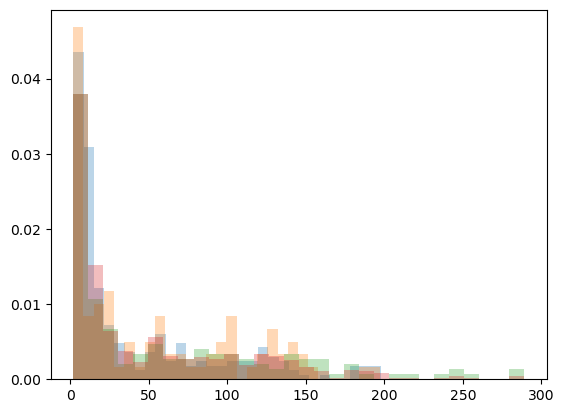

In [ ]:
plus_minus_df = []

# for experiment in ["s1", "s10","s11","s12"]
for experiment in ["s19", "s15","s14"]:
    df_temp = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusAndMinusTM.csv").dropna(subset=['TRACK_ID'])
    df_temp.TRACK_ID += (int(experiment.replace('s', ''))*1e6) # add expriment number as number of millions [1e6, 10e6, 11e6]
    df_temp["TIME"] = 1/4 * df_temp["FRAME"]

    plus_minus_df.append(
        df_temp
    )
    print(experiment, plus_minus_df[-1].TRACK_ID.max())
    print("Number of tracks: ", len(np.unique(plus_minus_df[-1].TRACK_ID)))
    _ = plt.hist(np.unique(plus_minus_df[-1].TRACK_ID, return_counts=True)[1], bins=30, alpha=.3, density=True)

plus_minus_df_ = pd.concat(plus_minus_df)

# plus_df_ = plus_minus_df_[plus_minus_df_.charge==.5].copy()
# minus_df_ = plus_minus_df_[plus_minus_df_.charge==-.5].copy()

# minimal_track = 5
# plus_df = plus_df_.groupby('TRACK_ID').filter(lambda x : len(x)>minimal_track).copy()
# minus_df = minus_df_.groupby('TRACK_ID').filter(lambda x : len(x)>minimal_track).copy()

# msd_plus_df = msd_from_df(plus_df,"x_img1","x_img1","TIME","TRACK_ID")
# msd_minus_df = msd_from_df(minus_df,"x_img1","x_img1","TIME","TRACK_ID")
_ = plt.hist(np.unique(plus_minus_df_.TRACK_ID, return_counts=True)[1], bins=30, alpha=.3, density=True)

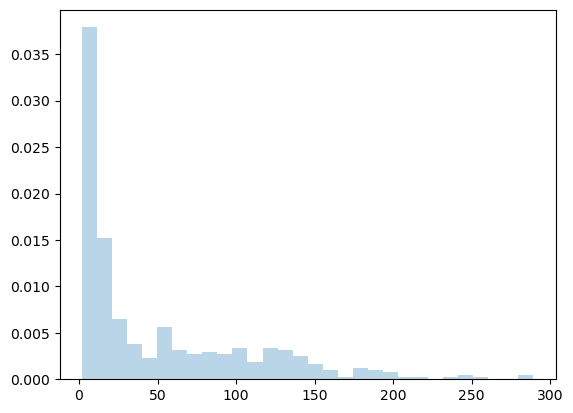

In [ ]:
_ = plt.hist(np.unique(plus_minus_df_.TRACK_ID, return_counts=True)[1], bins=30, alpha=.3, density=True)

Text(0.5, 1.0, 's1 | s10 | s11')

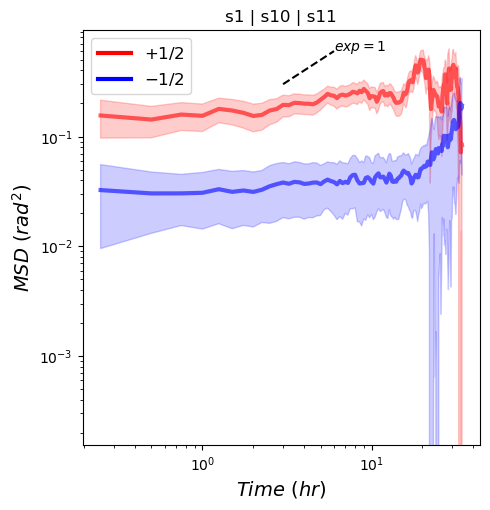

In [ ]:
# plus_minus_df["angm_ave"] = circmean(plus_minus_df[["ang1","ang2","ang2"]], high=2/3*np.pi, axis=1)
plus_minus_df_["angm_ave"] = plus_minus_df_["ang1"] % (2/3*np.pi)
plus_minus_df1 = plus_minus_df_[["ang1","angm_ave","charge","TIME","TRACK_ID", "FRAME"]]

msd_plus_df = ang_msd_from_df(plus_minus_df_[(plus_minus_df_.charge==.5)&(plus_minus_df_.FRAME>10)],
                              "ang1","TIME","TRACK_ID", minimal_track=20)
msd_minus_df = ang_msd_from_df(plus_minus_df1[(plus_minus_df1.charge==-.5)&(plus_minus_df1.FRAME>10)],
                               "angm_ave","TIME","TRACK_ID",period=2/3*np.pi, minimal_track=20)


# msd_plus_df = msd_from_df(plus_minus_df[plus_minus_df.charge==.5],"ang1","ang1","FRAME","TRACK_ID",minimal_track=10)
# msd_minus_df = msd_from_df(plus_minus_df1[plus_minus_df1.charge==-.5],"angm_ave","angm_ave","FRAME","TRACK_ID")

%matplotlib inline
fig, ax2 = plt.subplots(1,1, figsize=(5,5))
# msd_plus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="b", alpha=.05)
# msd_minus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="g", alpha=.05)

win = 1/4
 
for msd_df,color in zip([msd_plus_df, msd_minus_df], ["r","b"]):

    msd_df = msd_df.sort_values(by="FRAME")
    msd_df["ave"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.mean)
    msd_df["std"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.std)
    msd_df["count"] = roll_func(msd_df.MSD, msd_df.FRAME, win, np.sum)

    ax2.plot(msd_df.FRAME, msd_df["ave"], "-", color=color, alpha=.6, linewidth=3)
    ax2.fill_between(msd_df.FRAME, 
                    msd_df["ave"]-msd_df["std"]/msd_df["count"]**.5, 
                    msd_df["ave"]+msd_df["std"]/msd_df["count"]**.5, 
                    color=color, alpha=.2) 
    # TODO check the "count" 
    # break


ax2.plot([0,0],[0,0], "-", color="r", linewidth=3, label=r"$+1/2$")
ax2.plot([0,0],[0,0], "-", color="b", linewidth=3, label=r"$-1/2$")
xref = np.arange(3, 7, 1)
ax2.plot(xref, 1e-1*xref**1, "--k",)
ax2.text(xref[-1],  1e-1*xref[-1]**1, r"$exp=1$")
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel(r"$Time ~(hr)$", fontsize=14); ax2.set_ylabel(r"$MSD ~(rad^2)$", fontsize=14)
plt.legend(loc='upper left', fontsize=12); plt.tight_layout()
plt.title("s1"+" | s10"+" | s11")

## Pair Trajectories

In [116]:
all_pairs_df

,plus_id,xp,yp,angp1,min_id,xm,ym,angm1,angm2,angm3,...,fuse_up,p_vel_angle,p_vel_angle_rel,angp1_rel_vel_angle,fusion,creation,mp_angle1,mp_angle2,mp_angle3,mp_phase
FRAME,,,,,,,,,,,,,,,,,,,,,
33,19000281.0,1208.0,1868.0,-1.130973,19000004.0,1246.0,1915.0,-1.445133,2.827433,0.565487,...,True,0.000000,0.000000,5.152212,True,False,5.969026,3.958407,1.696460,-0.314159
34,19000281.0,1219.0,1882.0,-1.256637,19000004.0,1245.0,1917.0,2.827433,-1.382301,0.691150,...,True,0.000000,0.000000,5.026548,True,False,4.084070,6.157522,1.947787,-0.125664
35,19000281.0,1204.0,1854.0,-2.261947,19000004.0,1242.0,1908.0,0.691150,-1.319469,2.953097,...,True,0.000000,0.000000,4.021239,True,False,2.953097,0.942478,5.215044,0.942478
36,19000281.0,1200.0,1856.0,-2.638938,19000004.0,1242.0,1908.0,0.691150,-1.319469,2.953097,...,True,-2.158799,-3.050181,5.803046,True,False,3.330088,1.319469,5.592035,-0.774926
38,19000281.0,1210.0,1878.0,-1.382301,19000004.0,1231.0,1906.0,-3.141593,0.691150,-1.256637,...,True,-2.723368,-3.650664,1.341068,True,False,4.523893,2.073451,0.125664,0.145539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,14000410.0,1914.0,1438.0,2.387610,14000425.0,1921.0,1433.0,-2.701770,1.884956,-0.502655,...,True,0.000000,0.000000,2.387610,True,False,1.193805,5.780530,3.392920,-0.737059
95,14000410.0,1898.0,1442.0,-3.141593,14000425.0,1896.0,1399.0,-1.068142,-2.827433,0.753982,...,True,-1.695151,-6.361062,4.836744,True,False,2.073451,0.314159,3.895575,-0.003641
96,14000410.0,1908.0,1448.0,2.010619,14000425.0,1919.0,1439.0,1.822124,-2.764602,-0.628319,...,True,0.071307,-5.526148,1.939312,True,False,6.094690,1.507964,3.644247,-0.446302


In [74]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean, circstd
import os
import sys
import pandas as pd
pd.options.mode.chained_assignment = None
import seaborn as sns
import sys,time,random
sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

import matplotlib
matplotlib.rc('axes', edgecolor='k')
# plt.rcParams['xtick.color'] = 'k'
plt.rcParams['ytick.color'] = 'k'

PAIR_DIST_THRESH = 25 #C2C12:25 RPE1=15
MINIMAL_TRACK_LENGTH = 5
MINIMAL_TRACK_ANALYSIS = 10
DIST = 80 #C2C12:80 RPE1=50

def mp_phase(df):
    for i in range(3):
        df["mp_angle"+str(i+1)]  = (df["angm"+str(i+1)] - df.angp1) % (2*np.pi)

    mp_ang = []
    for i in range(3):
        mp_ang.append(df["mp_angle"+str(i+1)].values)
        
    return circmean(mp_ang, axis=0, low=-1/3*np.pi, high=1/3*np.pi)

all_pairs_df = []

# for experiment in ["s1", "s10","s11","s12"]: # cell type: RPE1
for experiment in ["s19", "s15","s14"]: # cell type: C2C12

    plus_minus_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusAndMinusTM.csv").dropna(subset=['TRACK_ID'])
    plus_minus_df.TRACK_ID += (int(experiment.replace('s', ''))*1e6) # add expriment number as number of millions [1e6, 10e6, 11e6]

    all_pairs_df.append(trajectory_pair_list(plus_minus_df, minimal_track=MINIMAL_TRACK_LENGTH, dist_thresh=PAIR_DIST_THRESH))
    print(all_pairs_df[-1].shape)
    print(experiment, all_pairs_df[-1].min_id.max())
    print("Number of tracks: ", len(np.unique(all_pairs_df[-1].min_id)))


all_pairs_df = pd.concat(all_pairs_df)
print("Total number of paired spots: ", all_pairs_df.shape[0])
''' -- ADD ---
1) distance btw pairs 
2)angle btw + and - centers 
3) fusion/creation 
'''
all_pairs_df["distance"] = (
    (all_pairs_df["xm"]-all_pairs_df["xp"])**2 + (all_pairs_df["ym"]-all_pairs_df["yp"])**2
    )**.5

all_pairs_df["mp_angle"] = np.arctan2(all_pairs_df["ym"]-all_pairs_df["yp"], 
                                      all_pairs_df["xm"]-all_pairs_df["xp"]) % (2*np.pi)


all_pairs_df["angp1_rel"] = (all_pairs_df["angp1"] - all_pairs_df["mp_angle"]) % (2*np.pi)
for i in range(3):
    all_pairs_df["angm"+str(i+1)+"_rel"] = (all_pairs_df["angm"+str(i+1)] - all_pairs_df["mp_angle"]) % (2*np.pi)

grouped = all_pairs_df.groupby('plus_id')["angp1_rel"]
all_pairs_df["fuse_up"] = grouped.transform(lambda x: circmean(x)>np.pi)

all_pairs_df["p_vel_angle"] = np.arctan2(all_pairs_df.groupby('plus_id')["yp"].diff(periods=3).fillna(0), 
                                        all_pairs_df.groupby('plus_id')["xp"].diff(periods=3).fillna(0))

all_pairs_df["p_vel_angle_rel"] = all_pairs_df["p_vel_angle"] - all_pairs_df["mp_angle"]                                 
all_pairs_df["p_vel_angle_rel"][all_pairs_df["p_vel_angle"]==0] = 0
# TODO p_angle relative to trajectory path
all_pairs_df["angp1_rel_vel_angle"] = (all_pairs_df["angp1"]- all_pairs_df["p_vel_angle"]) %(2*np.pi)

grouped = all_pairs_df.groupby('min_id')["distance"]
all_pairs_df["fusion"] = grouped.transform(lambda x: np.median(x.iloc[-len(x)//3:])<.9*np.median(x))

grouped = all_pairs_df.groupby('min_id')["distance"]
all_pairs_df["creation"] = grouped.transform(lambda x: np.median(x.iloc[:len(x)//3])<.9*np.median(x))

all_pairs_df["mp_phase"] = mp_phase(all_pairs_df)

print("Total number of paired trajectories: ", str(len(all_pairs_df.plus_id.unique())))

(2805, 10)
s19 19000350.0
Number of tracks:  136
(937, 10)
s15 15000070.0
Number of tracks:  28
(3910, 10)
s14 14000425.0
Number of tracks:  179
Total number of paired spots:  7652
Total number of paired trajectories:  311


In [5]:
# save_path = r"C:\Users\victo\OneDrive - BGU\C2C12_Trinish\RPE1_pairs.csv"
# all_pairs_df.to_csv(save_path)

In [58]:
# Import Dov's data
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean, circstd
import os
import sys
import pandas as pd
pd.options.mode.chained_assignment = None
import seaborn as sns
import sys,time,random
from joblib import Parallel, delayed

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\output_HBEC_s2.csv").dropna(subset=["min_id","creation"])
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\Bacteria_pairs.csv").dropna(subset=["min_id","creation"])
# all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\cellPairs_1_10_11_12.csv").dropna(subset=["min_id","creation"])
all_pairs_df = pd.read_csv(r"C:\Users\victo\OneDrive - BGU\Dov\cellPairs_14_15_19.csv").dropna(subset=["min_id","creation"])
all_pairs_df.fuse_up = all_pairs_df.fuse_up.astype("bool")
# all_pairs_df = all_pairs_df.groupby('plus_id').filter(lambda x: len(x)>5).copy()


(0.0, 235.72519369630294)

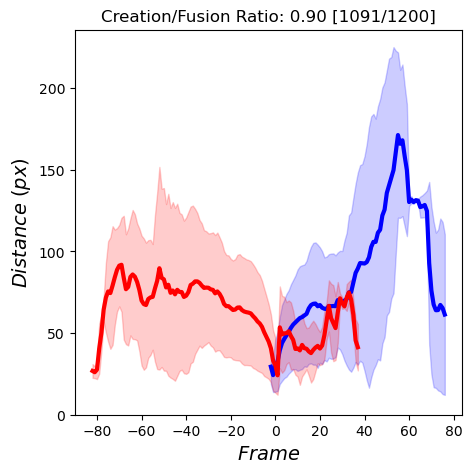

In [35]:
%matplotlib inline
fig, ax1 = plt.subplots(1,1,  figsize=(5,5))
show = False
win = 1

df_cr = all_pairs_df[all_pairs_df.creation].reset_index().copy()
df_cr["track_frame"] = df_cr.groupby(['min_id'])['FRAME'].transform(lambda x: x-x.iloc[0])

df_fuse = all_pairs_df[all_pairs_df.fusion].reset_index().copy()
df_fuse["track_frame"] = df_fuse.groupby(['min_id'])['FRAME'].transform(lambda x: x-x.iloc[-1])

df_all = pd.concat([df_cr,df_fuse])


# for color,df in zip(["b","r","k"], [df_cr, df_fuse, df_all]):
for color,df in zip(["b","r"], [df_cr, df_fuse]):    
    df_ = plot_rolling_average(df, ax1, "distance", "track_frame", win=win, show=show, color=color, avfunc=np.mean, stdfunc=np.std)
    if not show:
        ax1.plot(df_.track_frame, df_.distance_ave, color, linewidth=3)
        ax1.fill_between(df_.track_frame, 
                        df_.distance_ave-df_.distance_std, df_.distance_ave+df_.distance_std,
                        color=color, alpha=.2)

cr_n = len(all_pairs_df.plus_id[all_pairs_df.creation].unique())
fuse_n = len(all_pairs_df.plus_id[all_pairs_df.fusion].unique())

plt.title("Creation/Fusion Ratio: %.4s [%.4s/%.4s]" % (cr_n/fuse_n, cr_n, fuse_n))
ax1.set_xlabel("$Frame$", fontsize=14); ax1.set_ylabel("$Distance ~(px)$", fontsize=14)
ax1.set_ylim([0,None])


(10.833465492575998, 18.38769227124139)

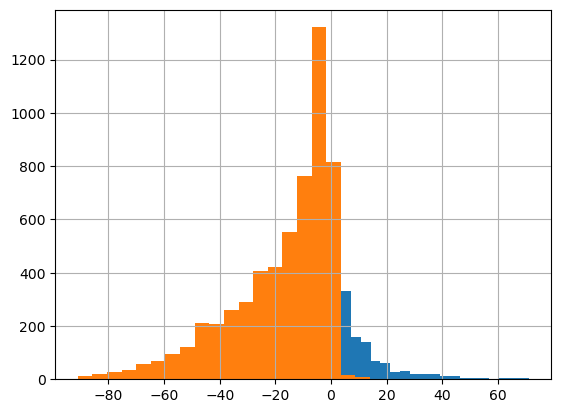

In [5]:
df_cr["track_frame"].hist(bins=20, density=False)
df_fuse["track_frame"].hist(bins=20, density=False)
df_cr["track_frame"].std(), df_fuse["track_frame"].std()

In [8]:
grouped = df_cr.groupby('min_id')["track_frame"]
df_cr["life"] = grouped.transform(lambda x: x.max())
df_cr["life"] 

0       32
1       32
2       32
3       32
4       32
        ..
3248     5
3249     5
3250     5
3251     5
3252     5
Name: life, Length: 3253, dtype: int64

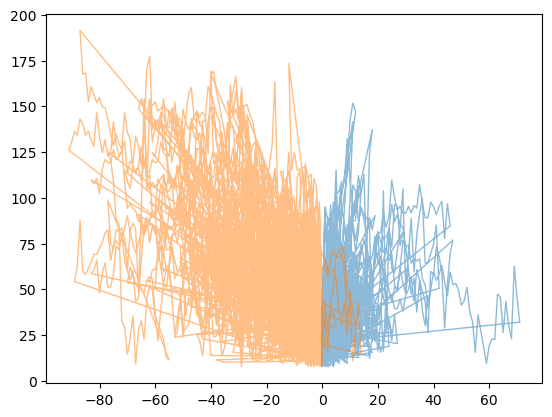

In [6]:
plt.plot(df_cr["track_frame"], df_cr["distance"], linewidth=1, alpha=.5)
plt.plot(df_fuse["track_frame"], df_fuse["distance"], linewidth=1, alpha=.5)

In [ ]:
rr

4104

(array([0.107443  , 0.10904663, 0.13951554, 0.17960621, 0.23894041,
        0.23412953, 0.22611139, 0.1491373 , 0.11706476, 0.10263212]),
 array([-3.1240241 , -2.50043765, -1.8768512 , -1.25326475, -0.62967829,
        -0.00609184,  0.61749461,  1.24108106,  1.86466751,  2.48825397,
         3.11184042]),
 <BarContainer object of 10 artists>)

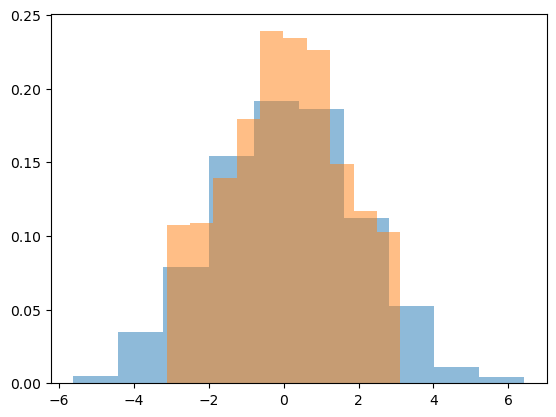

In [ ]:
# rolling average with angular data
df = pd.DataFrame(
    {"n": 2*np.random.randn(int(1e3))}
)

plt.hist(df.n, density=True, alpha=.5)
plt.hist(df.n.rolling(3, min_periods=1, center=True).apply(lambda x: circmean(x ,low=-np.pi,high=np.pi)), density=True, alpha=.5)

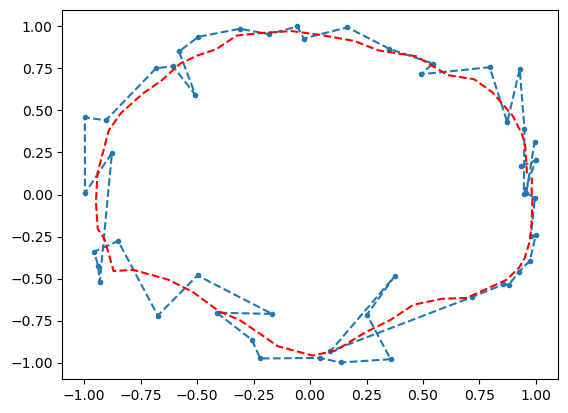

In [ ]:
%matplotlib inline
num_pnts = 50
t = np.linspace(0,6.6, num_pnts) 
x = np.cos(t + .2*np.random.randn(num_pnts))
y = np.sin(t + .2*np.random.randn(num_pnts))

df = pd.DataFrame({"x": x, "y": y})
plt.plot(df.x,df.y,"--.")


df.x = df.x.rolling(5, min_periods=1, center=True).mean()
df.y = df.y.rolling(5, min_periods=1, center=True).mean()
plt.plot(df.x,df.y,"--r")

In [ ]:
%matplotlib qt
def pair_fusion_frame(img, df, ax, frame_number=0):
    dt = -6 # creation:0 # fusion:-6
    dtt = dt+5
    ax.clear() 
    # plt.axis('off')   

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img)

    center = (np.median(df[["xp","xm"]][dt:dt+5]), np.median(df[["yp","ym"]][dt:dt+5]))
    # rot_angle = np.arctan2(np.median(df[["yp","ym"]][dt:-5]), np.median(df[["xp","xm"]][dt:-5]))*180/np.pi
    rot_angle = np.arctan2(
        np.median(df["ym"].iloc[dt:dt+5] - df["yp"].iloc[dt:dt+5]), 
        np.median(df["xm"].iloc[dt:dt+5] - df["xp"].iloc[dt:dt+5]), 
        )*180/np.pi
    
    # ax.imshow(255 - img, "gray")
    # ax.plot(center[0], center[1], "Xg", alpha=.6)
    # ax.quiver(df["xp"].iloc[dt:dtt], df["yp"].iloc[dt:dtt], np.cos(df["angp1"].iloc[dt:dtt]), -np.sin(df["angp1"].iloc[dt:dtt]), scale=3, color="r", alpha=.3, headwidth=0)    
    # ax.plot(df["xm"].iloc[dt:dtt], df["ym"].iloc[dt:dtt], "ob", alpha=.6)
    # for i in range(3):
    #     ax.quiver(df["xm"].iloc[dt:dtt], df["ym"].iloc[dt:dtt], 
    #         np.cos(df['angm'+str(i+1)].iloc[dt:dtt]), -np.sin(df['angm'+str(i+1)].iloc[dt:dtt]), scale=4, color="b", alpha=.3, headwidth=0)
    # img_crop = img

    width, height = 300, 300
    width1, height1 = int(width/2**.5), int(height/2**.5)
    img_crop, c = crop(255-img_clahe, center, width, height)    
    img_crop = rotate(img_crop, rot_angle)

    cnt_crop = img_crop.shape[1]/2, img_crop.shape[0]/2
    img_crop = crop(img_crop, cnt_crop, width1, height1)[0] 

    ax.imshow(img_crop, "gray")

    y, x = np.mgrid[0:img_crop.shape[1], 0:img_crop.shape[0]]
    sigma = 21
    s = 15
    ori, plus, min = analyze_defects(img_crop, sigma=sigma)

    alpha_half, scale_half = .9, 15 

    ax.quiver(x[::s,::s], y[::s,::s],
        np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], 
        headaxislength=0, headwidth=0, headlength=0, width=.008, 
        color="m", scale=2*scale_half, pivot='mid', alpha=.6*alpha_half)

    # # # original_vector = df[['xp','yp']].iloc[frame_number].to_numpy().T.reshape(2,-1)
    # # # rotated_vector = rotate_vector(original_vector, rot_angle, center) 
    # # # ax.plot(rotated_vector[0], rotated_vector[0],'ro',markersize=10, alpha=.8)

    ax.plot(plus['x'], plus['y'],'ro',markersize=6, alpha=.8)
    ax.quiver(plus['x'], plus['y'], 
        np.cos(plus['ang1']), -np.sin(plus['ang1']), 
        headaxislength=0, headwidth=0, headlength=0, color='r', scale=scale_half, alpha=alpha_half)

    ax.plot(min['x'], min['y'],'bo',markersize=6, alpha=.8)
    for i in range(3):
        ax.quiver(min['x'], min['y'], 
            np.cos(min['ang'+str(i+1)]), -np.sin(min['ang'+str(i+1)]), 
            headaxislength=0, headwidth=0, headlength=0, color='b', scale=scale_half, alpha=alpha_half)
        
    plt.title("%.1f (%s|%s)" % (rot_angle, frame_number, len(df)))
    plt.tight_layout()


# frame_num = 0
# for num,pid in enumerate(pairs_df.plus_id.unique()[3::1]):
#     df_ = pairs_df[pairs_df.plus_id==pid]
#     df_ = df_[df_.min_id.isin(df_.min_id.mode())] # select the longest min_id    

#     frames = df_.index.values.astype(int) 
#     img1 = cv2.imread(image_list[frames[frame_num]])[:,:,0]
#     fig, ax1 = plt.subplots(figsize=(4,4))
#     pair_fusion_frame(img1, df_, ax1, frame_number=frame_num)
#     break  

In [ ]:
def rotate_vector(vector, angle, origin):
    """
    Rotate a 2D vector counterclockwise by a given angle in degrees.

    Parameters:
    - vector: A 2D vector as a NumPy array [x, y]
    - angle: The rotation angle in degrees
    - origin: The rotation origin as a NumPy array [x, y]. If None, rotate around the vector itself.

    Returns:
    A new rotated 2D vector as a NumPy array [x', y']
    """
    # Translate the vector to the origin, rotate, and then translate it back
    translated_vector = vector - origin
    angle_rad = np.radians(angle)
    rotation_matrix = np.array([[np.cos(angle_rad), -np.sin(angle_rad)],
                                [np.sin(angle_rad), np.cos(angle_rad)]])
    rotated_vector = np.dot(rotation_matrix, translated_vector) + origin
    return rotated_vector

# # Example usage
# original_vector = df_[['xp','yp']].to_numpy().T.reshape(2,-1)  # Example vector along the x-axis
# angle_of_rotation = 90  # Example rotation angle in degrees
# rotation_origin = np.array([100, 100]).reshape(2,-1)  # Example rotation origin, the default is [0, 0]

# rotated_vector = rotate_vector(original_vector, angle_of_rotation, rotation_origin)
# print("Original Vector:", original_vector[:,:5].T)
# print("Rotated Vector:", rotated_vector[:,:5].T)


In [ ]:
from average_flows import * 
from matplotlib.animation import FuncAnimation
from scipy.ndimage import rotate, gaussian_filter
from matplotlib.animation import PillowWriter
writer = PillowWriter(fps=5)


%matplotlib qt

experiment = "s12" 

first_frame = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/MinusHalf1.csv')["frame"].min()
last_frame = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/MinusHalf1.csv')["frame"].max()

image_list_all = glob.glob(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei\*" + experiment + "*.tif")
image_list = natsorted(image_list_all, key=lambda y: y.lower())[first_frame-1:last_frame-1:1]

exp_label = int(experiment.replace('s', '')) * 1e6
pairs_df = df_all[(df_all.fusion) & (df_all.min_id>exp_label)&(df_all.min_id<exp_label+1e6)].copy()
# pairs_df = all_pairs_df.copy()

minimal_track = 10# MINIMAL_TRACK_ANALYSIS
pairs_df = pairs_df.groupby('plus_id').filter(lambda x: len(x)>minimal_track).copy()
print(len(pairs_df.plus_id.unique()[::1]))

ids = pairs_df.plus_id.unique()[::1]
for num,pid in enumerate(ids):
    df_ = pairs_df[pairs_df.plus_id==pid]
    df_ = df_[df_.min_id.isin(df_.min_id.mode())] # select the longest min_id

    frames = df_.FRAME.values #.index.values.astype(int) 
        
    fig, ax1 = plt.subplots(figsize=(4,4))
    plt.axis('off')
    plt.gca().set_aspect('equal')

    def update(frame):
        # ax1.clear()
        if (frames[0]+frame)<(last_frame-first_frame) and all(df_[["xp","xm","yp","ym"]]>250):

            iframe = frames[0]-5 if frames[0]>5 else frames[0]
            
            img1 = cv2.imread(image_list[iframe+frame])[:,:,0]
            try:
                pair_fusion_frame(img1, df_, ax1, frame_number=frame)
            except:
                pass
        return

    anim = FuncAnimation(fig, update, frames=len(frames)+10, interval=100) #np.min([len(frames)-1, last_frame-first_frame-1])
    save_path = os.path.join(
        # r"C:\Users\victo\OneDrive - BGU\C2C12_Trinish\Creation_C2C12_2", 
        r"C:\Users\victo\OneDrive - BGU\C2C12_Trinish\Fusion_RPE1_2", 
        "id_%.0f" % pid + ".gif"        
        )
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    anim.save(save_path, writer=writer) 

    progressBar(num, len(ids))
    # break
    plt.close(fig)
    plt.pause(1)  
      

    # if num>3:
    #     break

# plt.gca().set_box_aspect(1)
# plt.gca().set_aspect('equal')

25


Traceback (most recent call last):
  File "c:\Users\victo\miniconda3\envs\cellpose\lib\site-packages\matplotlib\cbook\__init__.py", line 307, in process
    func(*args, **kwargs)
  File "c:\Users\victo\miniconda3\envs\cellpose\lib\site-packages\matplotlib\animation.py", line 903, in _start
    self.event_source.add_callback(self._step)
AttributeError: 'NoneType' object has no attribute 'add_callback'


In [ ]:
# %matplotlib qt

# experiment = "s1" 

# first_frame = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/MinusHalf1.csv')["frame"].min()
# last_frame = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/MinusHalf1.csv')["frame"].max()

# image_list_all = glob.glob(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei\*" + experiment + "*.tif")
# image_list = natsorted(image_list_all, key=lambda y: y.lower())[first_frame-1:last_frame-1:1]


# exp_label = int(experiment.replace('s', '')) * 1e6
# pairs_df = all_pairs_df[(all_pairs_df.min_id>exp_label)&(all_pairs_df.min_id<2*exp_label)].copy()
# pairs_df = all_pairs_df.copy()

# minimal_track = MINIMAL_TRACK_ANALYSIS
# pairs_df = pairs_df.groupby('plus_id').filter(lambda x: len(x)>minimal_track).copy()

# distance_in_time = []

# fig, ax1 = plt.subplots(1,1,  figsize=(6,6))
# img1 = cv2.imread(image_list[50])[:,:,0]
# clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
# img_clahe = clahe.apply(img1)
# ax1.imshow(255-img_clahe, "gray")


# y, x = np.mgrid[0:img1.shape[0], 0:img1.shape[1]]
# sigma =  30
# s = 15
# ori, plus, min = analyze_defects(img1, sigma=sigma)

# ax1.quiver(x[::s,::s], y[::s,::s],
#     np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], 
#     headaxislength=0, headwidth=0, headlength=0, width=.008, 
#     color="k", scale=35, pivot='mid', alpha=.5)


# for num,pid in enumerate(pairs_df.plus_id.unique()[::1]):
#     df_ = pairs_df[pairs_df.plus_id==pid]
#     df_ = df_[df_.min_id.isin(df_.min_id.mode())] # select the longest min_id
#     df_["TIME"] = df_.reset_index()["FRAME"].values # set last TIME to be ZERO
#     df_.TIME -= df_.TIME.iloc[-1]
#     df_i = pd.DataFrame({
#         "time": df_.TIME,
#         "distance": df_.distance,
#         "fuse_up": df_.fuse_up,
#         "mp_phase": mp_phase(df_),
#         "p_ang_rel": df_.angp1_rel,
#         })
#     df_i.mp_phase = df_i.mp_phase.rolling(7, min_periods=1, center=True).apply(lambda x: circmean(x ,low=-1/3*np.pi,high=1/3*np.pi))
#     distance_in_time.append(df_i)
    
#     trajectory = df_.TIME.abs().values + 1
#     roll_win = 1

#     # ax1.plot(df_.xp.iloc[-3:], df_.yp.iloc[-3:],"+k")
#     ax1.scatter(df_.xp, df_.yp, c=trajectory, s=(300/trajectory)**1.1, cmap='Reds_r', alpha=0.2)
#     df_.xp = df_.xp.rolling(roll_win, min_periods=1, center=True).mean()_r
#     df_.yp = df_.yp.rolling(roll_win, min_periods=1, center=True).mean()
#     ax1.plot(df_.xp, df_.yp,'r', linewidth=3, alpha=0.3)
#     ax1.quiver(df_.xp.iloc[:-1], df_.yp.iloc[:-1], df_.xp.diff().dropna(), -df_.yp.diff().dropna(), 
#                color='r', alpha=0.6)

#     # ax1.plot(df_.xm.iloc[-3:], df_.ym.iloc[-3:],"+k")
#     ax1.scatter(df_.xm, df_.ym, c=trajectory, s=(300/trajectory)**1.1, cmap='Blues_r', alpha=0.2)
#     df_.xm = df_.xm.rolling(roll_win, min_periods=1, center=True).mean()
#     df_.ym = df_.ym.rolling(roll_win, min_periods=1, center=True).mean()
#     ax1.plot(df_.xm, df_.ym,'b', linewidth=3, alpha=0.3)
#     ax1.quiver(df_.xm.iloc[:-1], df_.ym.iloc[:-1], df_.xm.diff().dropna(), -df_.ym.diff().dropna(), 
#                color='b', alpha=0.6)

#     ax1.plot(df_[["xp","xm"]].iloc[-2:].mean(axis=0),df_[["yp","ym"]].iloc[-2:].mean(axis=0),"k", linewidth=3, alpha=0.6)
#     # break
#     # if num>3:
#     #     break
    
#     # if not all(distance_in_time[-1].fuse_up):
#     #     ax1.plot(distance_in_time[-1].time, 
#     #             180/np.pi * distance_in_time[-1].mp_phase,
#     #             "og", alpha=.1, linewidth=3)
#     # else:
#     #     ax1.plot(distance_in_time[-1].time, 
#     #             180/np.pi * distance_in_time[-1].mp_phase,
#     #             "ob", alpha=.1, linewidth=3)        

# plt.gca().set_box_aspect(1)
# plt.title("Number of paired trajectories: " + str(num))
# plt.gca().set_aspect('equal')

# distance_in_time = pd.concat(distance_in_time)

In [ ]:
# df = all_pairs_df[all_pairs_df.fusion].reset_index().copy()
# df["track_frame"] = df.groupby(['min_id'])['FRAME'].transform(lambda x: x-x.iloc[-1])
# df = all_pairs_df[~all_pairs_df.fusion].reset_index().copy()
# df["track_frame"] = df.groupby(['min_id'])['FRAME'].transform(lambda x: x-x.iloc[0])

df = all_pairs_df[all_pairs_df.creation].reset_index().copy()
df["track_frame"] = df.groupby(['min_id'])['FRAME'].transform(lambda x: x-x.iloc[0])

(0.0, 200.0)

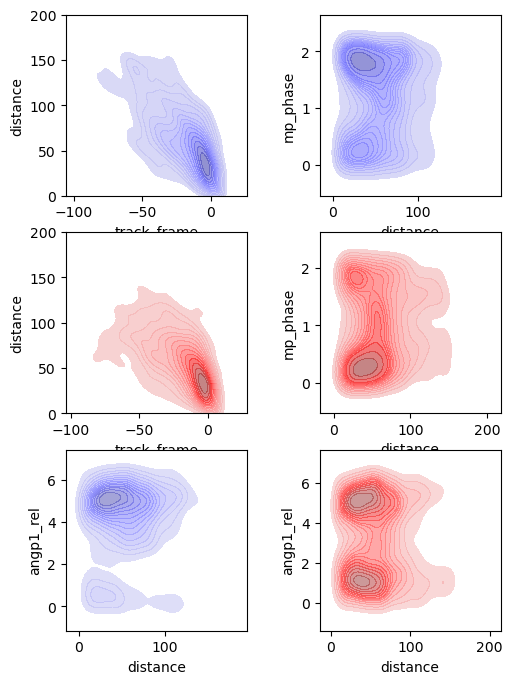

In [7]:
%matplotlib inline
import seaborn as sns
fig, axs = plt.subplots(3, 2, figsize=(6,8))
ax1,ax2,ax3,ax4, ax5, ax6 = axs.ravel()
levels = 15
# sns.kdeplot(data=distance_in_time[distance_in_time.fuse_up], x="time", y="mp_phase", ax=ax2, levels=levels, color="Red", alpha=.6, fill=True)

distance_in_time = df

sns.kdeplot(data=distance_in_time[distance_in_time.fuse_up], x="track_frame", y="distance", ax=ax1, levels=levels, color="Blue", alpha=.6, fill=True)
sns.kdeplot(data=distance_in_time[~distance_in_time.fuse_up], x="track_frame", y="distance", ax=ax3, levels=levels, color="Red", alpha=.6, fill=True)
sns.kdeplot(data=distance_in_time[~distance_in_time.fuse_up], x="distance", y="mp_phase", ax=ax2, levels=levels, color="Blue", alpha=.6, fill=True)
sns.kdeplot(data=distance_in_time[distance_in_time.fuse_up], x="distance", y="mp_phase", ax=ax4, levels=levels, color="Red", alpha=.6, fill=True)
sns.kdeplot(data=distance_in_time[~distance_in_time.fuse_up], x="distance", y="angp1_rel", ax=ax5, levels=levels, color="Blue", alpha=.5, fill=True)
# sns.kdeplot(data=distance_in_time[distance_in_time.fuse_up], x="distance", y="angp1_rel", ax=ax6, levels=levels, color="Red", alpha=.5, fill=True)
sns.kdeplot(data=distance_in_time, x="distance", y="angp1_rel", ax=ax6, levels=levels, color="Red", alpha=.5, fill=True)

[ax.set_box_aspect(1) for ax in axs.ravel()]
ax1.set_ylim([0,200])
ax3.set_ylim([0,200])
    
    # ax2.set_ylim([0,200])

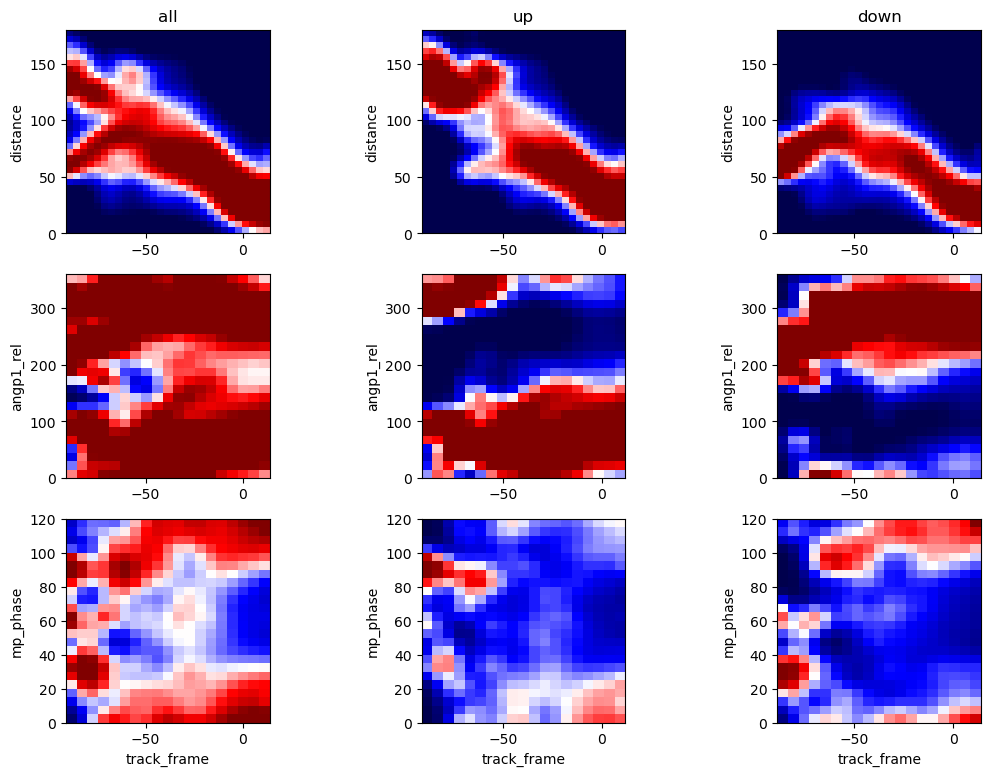

In [8]:
%matplotlib inline

from matplotlib.colors import LogNorm

def df_2d_hist(x, y, xres, yres, norm=True, sigma=None, xlim=None, ylim=None):
    if xlim:
        xedges = np.linspace(xlim[0], xlim[1], xres)
    else:
        xedges = np.linspace(int(np.floor(x.min())), int(np.ceil(x.max())), xres)
    
    if ylim:
        yedges = np.linspace(ylim[0], ylim[1], yres)
    else:
        yedges = np.linspace(int(np.floor(y.min())), int(np.ceil(y.max())), yres)
    hist, xedges, yedges = np.histogram2d(x, y, bins=(xedges, yedges))

    hist = gaussian_filter(hist.T, sigma=sigma) if sigma else hist.T

    if norm:
        with np.errstate(divide='ignore', invalid='ignore'):  # suppress division by zero warnings
            hist /= hist.sum(axis=0, keepdims=True)

    return hist, xedges, yedges


dfs =  [distance_in_time, distance_in_time[distance_in_time.fuse_up], distance_in_time[~distance_in_time.fuse_up]]
labels = ["all", "up", "down"]

fig, axs = plt.subplots(3,3, figsize=(13, 9))
axs = axs.ravel()

xlabel = "track_frame"
ylabel = "distance"

for ax, df, label in zip(axs[:3], dfs, labels):
    dist_hist, xedges, yedges = df_2d_hist(df[xlabel], 
                                      df[ylabel], 
                                      30, 35, norm=True, sigma=1.5, 
                                    #   xlim=(-65,0), 
                                    ylim=(0,180)
                                      )
    c= ax.pcolormesh(xedges, yedges, dist_hist, cmap='seismic',
                     vmin=.05*dist_hist.max(), vmax=.5*dist_hist.max())#, norm=LogNorm())
    ax.set_title(label); ax.set_ylabel(ylabel); ax.set_box_aspect(1)

ylabel = "angp1_rel"
for ax, df, label in zip(axs[3:6], dfs, labels):
    hist, xedges, yedges = df_2d_hist(df[xlabel], 
                                      180/np.pi* df[ylabel], 
                                      20, 25, norm=True, sigma=1)
    c= ax.pcolormesh(xedges, yedges, hist, cmap='seismic',
                     vmin=.01*hist.max(),  vmax=.3*hist.max())#, norm=LogNorm())
    ax.set_ylabel(ylabel); ax.set_box_aspect(1)    

ylabel = "mp_phase"
for ax, df, label in zip(axs[6:], dfs, labels):
    hist, xedges, yedges = df_2d_hist(df[xlabel], 
                                      180/np.pi* df[ylabel], 
                                      20, 25, norm=True, sigma=1)
    c= ax.pcolormesh(xedges, yedges, hist, cmap='seismic',
                     vmin=.01*hist.max(),  vmax=.8*hist.max())#, norm=LogNorm())
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_box_aspect(1)

    

In [ ]:
i1

NameError: name 'i1' is not defined

#### How +1/2 defects orient ralatively to axis of their movement

In [ ]:
len(all_pairs_df.plus_id[all_pairs_df.fusion].unique())

127

In [10]:
%matplotlib inline
bins_number = 15  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2*np.pi, bins_number+1) #* 180/np.pi
width = 2 * np.pi / bins_number

all_pairs_df = df_fuse

df = all_pairs_df[~all_pairs_df.fusion].reset_index()
up = df["angp1_rel_vel_angle"][(df["fuse_up"])&(df.distance<200)]
down = df["angp1_rel_vel_angle"][~(df["fuse_up"])&(df.distance<200)]

plt.figure(figsize=(8,4))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')
# p0,_,_ = ax1.hist(all*180/np.pi, bins*180/np.pi, alpha=.4, density=True, rwidth=.9, color="r")
p1,_,_ = ax1.hist(up*180/np.pi, bins*180/np.pi, alpha=.4, density=True, rwidth=.9, color="b")
p2,_,_ = ax1.hist(down*180/np.pi, bins*180/np.pi, alpha=.4, density=True, rwidth=.9, color="g")

# ax2.bar(bins[:bins_number], p0, color="r", width=width, bottom=0., alpha=.4)
ax2.bar(bins[:bins_number], p1, color="b", width=width, bottom=0., alpha=.4,
    label=r"%.1f $(\langle \theta \rangle _{tr} > \pi)$" % (circmean(up, high=np.pi)*180/np.pi))
    # label="up: %.1f" % (circmean(up, high=np.pi)*180/np.pi))
ax2.bar(bins[:bins_number], p2, color="g", width=width, bottom=0., alpha=.4,
    label=r"%.1f $(\langle \theta \rangle _{tr} < \pi)$"  % (circmean(down, high=np.pi)*180/np.pi))
# ax2.legend(fontsize=12)
ax1.set_title("Angle of +1/2 defect movement \n its trajectory axis")

KeyError: "None of [Int64Index([-2, -2, -2, -2, -2, -2, -2, -2, -2, -2,\n            ...\n            -2, -2, -2, -2, -2, -2, -2, -2, -2, -2],\n           dtype='int64', length=5714)] are in the [columns]"

#### How +1/2 defects move ralatively to axis between defect pair

Text(0.5, 1.0, 'Close vs Far')

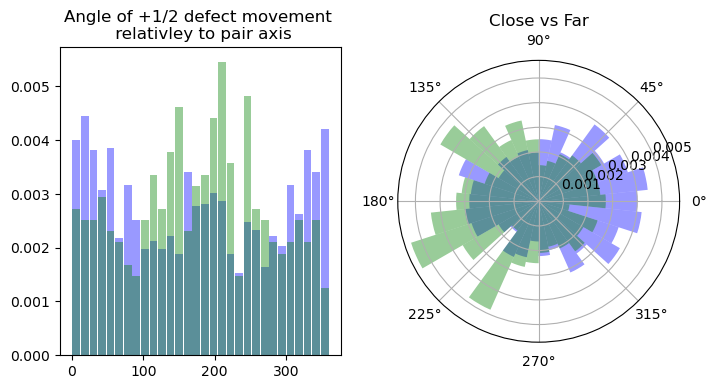

In [ ]:
%matplotlib inline
dist = DIST

bins_number = 30  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2*np.pi, bins_number+1) #* 180/np.pi
bins_ = np.linspace(0, 2*np.pi, bins_number) #* 180/np.pi
width = 2 * np.pi / bins_number

# all = all_pairs_df["p_vel_angle_rel"][~(all_pairs_df["p_vel_angle"]==0)] % (2*np.pi)
# up = all_pairs_df["p_vel_angle_rel"][(all_pairs_df["fuse_up"]) & ~(all_pairs_df["p_vel_angle"]==0)] % (2*np.pi)
# down = all_pairs_df["p_vel_angle_rel"][~(all_pairs_df["fuse_up"]) & ~(all_pairs_df["p_vel_angle"]==0)] % (2*np.pi)
# ------- early/late
up = all_pairs_df["p_vel_angle_rel"][(all_pairs_df.fusion) & ~(all_pairs_df["p_vel_angle"]==0) & (all_pairs_df.distance<dist)] % (2*np.pi)
down = all_pairs_df["p_vel_angle_rel"][(all_pairs_df.fusion) & ~(all_pairs_df["p_vel_angle"]==0) & (all_pairs_df.distance>dist)] % (2*np.pi)


plt.figure(figsize=(8,4))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')
# p0,_,_ = ax1.hist(all*180/np.pi, bins*180/np.pi, alpha=.4, density=True, rwidth=.9, color="r")
p1,_,_ = ax1.hist(up*180/np.pi, bins*180/np.pi, alpha=.4, density=True, rwidth=.9, color="b")
p2,_,_ = ax1.hist(down*180/np.pi, bins*180/np.pi, alpha=.4, density=True, rwidth=.9, color="g")

# ax2.bar(bins_, p0, color="r", width=width/2, bottom=0., alpha=.4)
# ax2.fill_between(bins_, p0, color="r",alpha=.4)
ax2.bar(bins[:bins_number], p1, color="b", width=width, bottom=0., alpha=.4,
    label=r"%.1f $(\langle \theta \rangle _{tr} > \pi)$" % (circmean(up, high=np.pi)*180/np.pi))
    # label="up: %.1f" % (circmean(up, high=np.pi)*180/np.pi))
ax2.bar(bins[:bins_number], p2, color="g", width=width, bottom=0., alpha=.4,
    label=r"%.1f $(\langle \theta \rangle _{tr} < \pi)$"  % (circmean(down, high=np.pi)*180/np.pi))
# ax2.legend(fontsize=12)
ax1.set_title("Angle of +1/2 defect movement \n relativley to pair axis")
ax2.set_title("Close vs Far")

# print(
#     " up: %.1f [std: %.1f] \n down: %.1f [std: %.1f] \n all: %.1f [std: %.1f]"
#     % (circmean(up, high=np.pi)*180/np.pi, circstd(up, high=np.pi)*180/np.pi,
#     circmean(down, high=np.pi)*180/np.pi, circstd(down, high=np.pi)*180/np.pi,
#     circmean(all, high=np.pi)*180/np.pi, circstd(all, high=np.pi)*180/np.pi)
#     )

Text(0.5, 1.0, '$dist>60$')

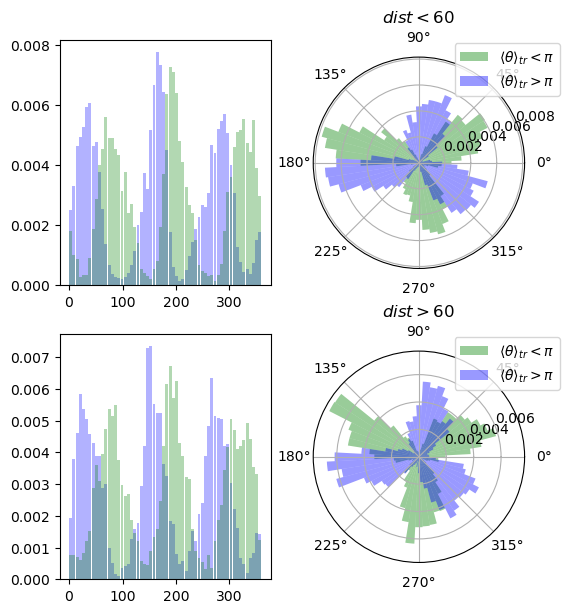

In [13]:
%matplotlib inline
df_all = df_fuse#all_pairs_df[all_pairs_df.creation].copy()
dist = DIST = 60
m_ang_up_close, m_ang_down_close = [], []
m_ang_up_far, m_ang_down_far = [], []
for i in range(3):
    m_ang_up_close.append(df_all["angm"+str(i+1)+"_rel"][np.logical_and(
        df_all["fuse_up"], df_all["distance"]<dist)].values)
    m_ang_down_close.append(df_all["angm"+str(i+1)+"_rel"][np.logical_and(
        ~df_all["fuse_up"], df_all["distance"]<dist)].values)
    m_ang_up_far.append(df_all["angm"+str(i+1)+"_rel"][np.logical_and(
        df_all["fuse_up"], df_all["distance"]>dist)].values)
    m_ang_down_far.append(df_all["angm"+str(i+1)+"_rel"][np.logical_and(
        ~df_all["fuse_up"], df_all["distance"]>dist)].values)
    # break
    
m_ang_up_close = np.concatenate(m_ang_up_close) 
m_ang_down_close = np.concatenate(m_ang_down_close) 
m_ang_up_far = np.concatenate(m_ang_up_far) 
m_ang_down_far = np.concatenate(m_ang_down_far) 

fig1 = plt.figure(figsize=(6,7))
ax1 = plt.subplot(221)
ax2 = plt.subplot(222, projection='polar')
ax3 = plt.subplot(223)
ax4 = plt.subplot(224, projection='polar')

bins_number = 60  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2*np.pi, bins_number+1) #* 180/np.pi
width = 2 * np.pi / bins_number

# p2,_,_ = ax1.hist(360-(-m_ang_down_close % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak flipped
# p2,_,_ = ax1.hist(m_ang_down_close % (2/3*np.pi)*180/np.pi, bins*180/np.pi, #one peak 
p2,_,_ = ax1.hist((m_ang_down_close % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="b")
# p1,_,_ = ax1.hist((m_ang_up_close % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak
p1,_,_ = ax1.hist((m_ang_up_close % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="g")

ax2.bar(bins[:bins_number], p2, color="green", width=width, bottom=0.0, alpha=.4,
                    label=r"$\langle \theta \rangle _{tr} < \pi$")
ax2.bar(bins[:bins_number], p1, color="blue", width=width, bottom=0.0, alpha=.4,
                    label=r"$\langle \theta \rangle _{tr} > \pi$")

ax2.legend(bbox_to_anchor=(1.2, 1.1)); ax2.set_title(r"$dist<%s$" % dist)

# p4,_,_ = ax3.hist(360-(-m_ang_down_far % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak flipped
# p4,_,_ = ax3.hist((m_ang_down_far % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak
p4,_,_ = ax3.hist(m_ang_down_far % (2*np.pi)*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="b")
# p3,_,_ = ax3.hist((m_ang_up_far % (2/3*np.pi))*180/np.pi, bins*180/np.pi, #one peak
p3,_,_ = ax3.hist((m_ang_up_far % (2*np.pi))*180/np.pi, bins*180/np.pi, #three peaks
                    density=True, rwidth=.9, alpha=.3, color="g")


ax4.bar(bins[:bins_number], p4, color="green", width=width, bottom=0.0, alpha=.4,
                    label=r"$\langle \theta \rangle _{tr} < \pi$")
ax4.bar(bins[:bins_number], p3, color="blue", width=width, bottom=0.0, alpha=.4,
                    label=r"$\langle \theta \rangle _{tr} > \pi$")

ax4.legend(bbox_to_anchor=(1.2, 1.1)); ax4.set_title(r"$dist>%s$" % dist)

Text(0, 0.5, '$Angle ~between ~defect ~pair ~axis$\n$~and ~-1/2 ~orientation$')

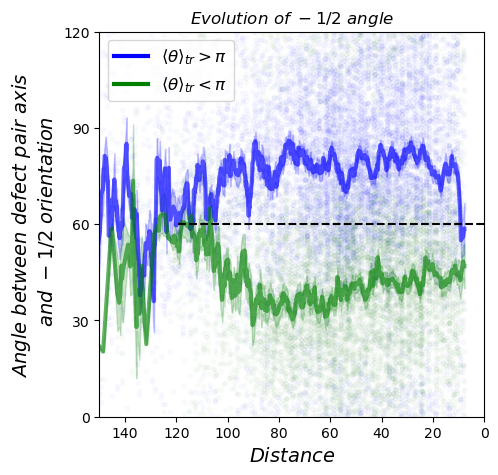

In [17]:
%matplotlib inline

df_all = df_fuse#all_pairs_df[all_pairs_df.creation].copy()
win = 1

fig, ax1 = plt.subplots(1,1,  figsize=(5,5))

for i in range(3):
    y_up = df_all["angm"+str(i+1)+"_rel"][df_all["fuse_up"]] % (2/3*np.pi)
    y_down = df_all["angm"+str(i+1)+"_rel"][~df_all["fuse_up"]] % (2/3*np.pi)
    ax1.plot(df_all.distance[df_all["fuse_up"]], y_up*180/np.pi, ".b", alpha=.02)
    ax1.plot(df_all.distance[~df_all["fuse_up"]], y_down*180/np.pi, ".g", alpha=.02)
    # plt.plot(df_all.distance[~fuse_df["fuse_up"]], -120+(y_down*180/np.pi), "og", alpha=.02)

m_ang_all = []
for i in range(3):
    m_ang_all.append(df_all["angm"+str(i+1)+"_rel"].values)
    # break
    
df_all["angm_rel_all"] = circmean(np.array(m_ang_all) % (2/3*np.pi), axis=0) % (2/3*np.pi)

df = df_all[df_all["fuse_up"]]
df_av_up = plot_rolling_average(df, ax1, "angm_rel_all", "distance", win=win, color="b", high=2/3*np.pi)
ax1.plot([0,0],[0,0], "-b", linewidth=3, label=r"$\langle \theta \rangle _{tr} > \pi$")


df = df_all[~df_all["fuse_up"]]
df_av_down = plot_rolling_average(df, ax1, "angm_rel_all", "distance", win=win, color="g", high=2/3*np.pi)
ax1.plot([0,0],[0,0], "-", color="g", linewidth=3, label=r"$\langle \theta \rangle _{tr} < \pi$")


plt.xlim([0,150]); plt.ylim([0,120]); plt.yticks(np.arange(0, 121, 30))
plt.plot([0,120],[60,60],"--k")
plt.gca().set_box_aspect(1); plt.gca().invert_xaxis()
plt.legend(loc='upper left', fontsize=12); plt.title("$Evolution ~of ~-1/2 ~angle$")
plt.xlabel("$Distance$", fontsize=14)
plt.ylabel(r"$Angle ~between ~defect ~pair ~axis$" +"\n" + r"$~and ~-1/2 ~orientation$", fontsize=14) 
# df_av_down.angm_rel_all_ave.head(), df_av_up.angm_rel_all_ave.tail()

Text(0.5, 1.0, '$dist<80$')

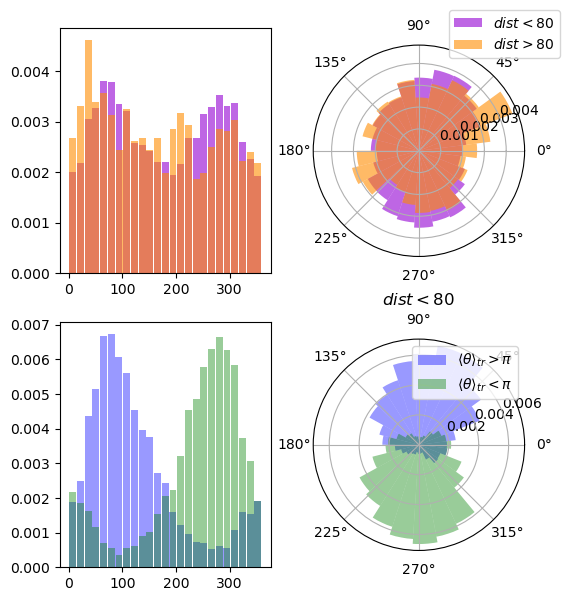

In [41]:
%matplotlib inline
dist = 80
bins_number = 25  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2*np.pi, bins_number+1)
width = 2 * np.pi / bins_number

# df_all = df_cr#all_pairs_df[all_pairs_df.creation].copy()
df_all = df_fuse#all_pairs_df[all_pairs_df.creation].copy()

y = (df_all["angp1_rel"]) % (2*np.pi)
# y_close = (df_all["angp1_rel"][df_all.index<30]) % (2*np.pi)
# y_far = (df_all["angp1_rel"][df_all.index>60]) % (2*np.pi)
y_close = (df_all["angp1_rel"][df_all["distance"]<dist]) % (2*np.pi)
y_far = (df_all["angp1_rel"][df_all["distance"]>dist]) % (2*np.pi)
y_up = (df_all["angp1_rel"][(df_all["fuse_up"])&(df_all["distance"]<dist)]) % (2*np.pi)
y_down = (df_all["angp1_rel"][(~df_all["fuse_up"])&(df_all["distance"]<dist)]) % (2*np.pi)

plt.figure(figsize=(6,7))
ax1 = plt.subplot(221)
ax2 = plt.subplot(222, projection='polar')
ax3 = plt.subplot(223)
ax4 = plt.subplot(224, projection='polar')

# p1,_,_ = ax1.hist(y*180/np.pi, bins_number, alpha=.3, density=True, rwidth=.9)
p1,_,_ = ax1.hist(y_close*180/np.pi, bins_number, alpha=.6, density=True, rwidth=.9, color="darkviolet")
p2,_,_ = ax1.hist(y_far*180/np.pi, bins_number, alpha=.6, density=True, rwidth=.9, color="darkorange")
p3,_,_ = ax3.hist(y_up*180/np.pi, bins_number, alpha=.4, density=True, rwidth=.9, color="b")
p4,_,_ = ax3.hist(y_down*180/np.pi, bins_number, alpha=.4, density=True, rwidth=.9, color="g")


ax2.bar(bins[:bins_number], p1, color="darkviolet", width=width, bottom=0., alpha=.6, label="$dist<%s$" %dist)
ax2.bar(bins[:bins_number], p2, color="darkorange", width=width, bottom=0., alpha=.6, label="$dist>%s$" %dist)
ax4.bar(bins[:bins_number], p3, color="b", width=width, bottom=0., alpha=.4, label=r"$\langle \theta \rangle _{tr} > \pi$")
ax4.bar(bins[:bins_number], p4, color="g", width=width, bottom=0., alpha=.4, label=r"$\langle \theta \rangle _{tr} < \pi$")
ax2.legend(bbox_to_anchor=(1.2, 1.2)); ax4.legend()
ax4.set_title("$dist<%s$" %dist)

Text(0, 0.5, '$Angle$')

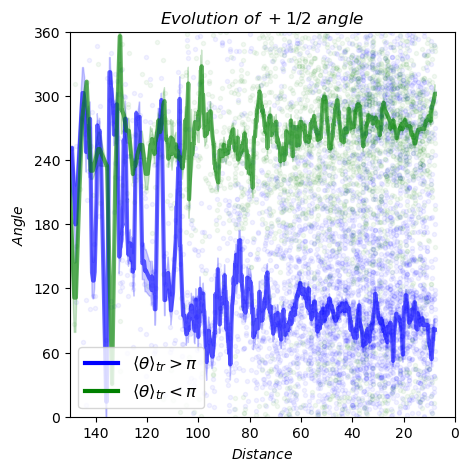

In [50]:
%matplotlib inline

fig, ax1 = plt.subplots(1,1,  figsize=(5,5))

df_all = df_cr#all_pairs_df[all_pairs_df.fusion].copy()
# df_all = df_fuse#all_pairs_df[all_pairs_df.creation].copy()

ax1.plot(df_all.distance[df_all["fuse_up"]], df_all.angp1_rel[df_all["fuse_up"]]*180/np.pi, ".b", alpha=.05)
ax1.plot(df_all.distance[~df_all["fuse_up"]], df_all.angp1_rel[~df_all["fuse_up"]]*180/np.pi, ".g", alpha=.05)

win = 1
  
df = df_all[df_all["fuse_up"]]
df_av_up = plot_rolling_average(df, ax1, "angp1_rel", "distance", win=win, color="b")
ax1.plot([0,0],[0,0], "-b", linewidth=3, label=r"$\langle \theta \rangle _{tr} > \pi$")


df = df_all[~df_all["fuse_up"]]
df_av_down = plot_rolling_average(df, ax1, "angp1_rel", "distance", win=win, color="g")
ax1.plot([0,0],[0,0], "-g", linewidth=3, label=r"$\langle \theta \rangle _{tr} < \pi$")


plt.xlim([0,150]); plt.ylim([-0,360]); plt.yticks(np.arange(0, 361, 60))
plt.gca().set_box_aspect(1); plt.gca().invert_xaxis()
plt.legend(fontsize=12); plt.title("$Evolution ~of ~+1/2 ~angle$")
plt.xlabel("$Distance$"); plt.ylabel("$Angle$")

## Relative angle between defects in a pair

Text(0.5, 1.0, '$Relative ~angle ~btw ~-1/2 ~and ~+1/2 ~defects$')

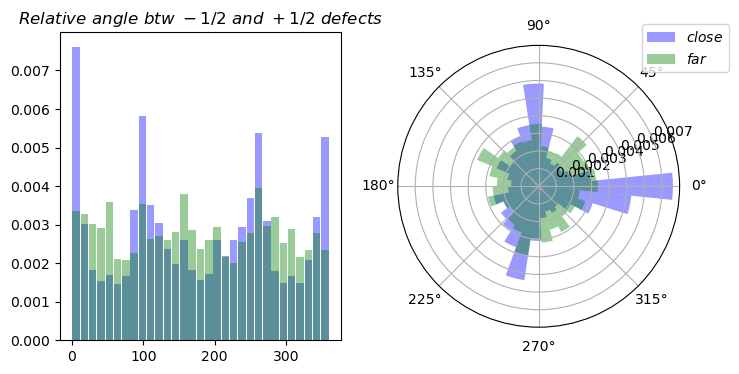

In [49]:
fig1 = plt.figure(figsize=(8,4))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')
bins_number = 31  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2*np.pi, bins_number+1) #* 180/np.pi
width = 2 * np.pi / bins_number
dist = 60


df_all = df_cr#all_pairs_df[all_pairs_df.fusion].copy()
# df_all = df_fuse#all_pairs_df[all_pairs_df.creation].copy()

m_ang_all = []
for i in range(3):
    df_all["mp_angle"+str(i+1)]  = (df_all["angm"+str(i+1)] - df_all.angp1) % (2*np.pi)

mp_ang = []
mp_ang_all = []
mp_ang_all_far = []
mp_ang_up = []
mp_ang_down = []
for i in range(3):
    mp_ang.append(df_all["mp_angle"+str(i+1)].values)
    mp_ang_all.append(df_all["mp_angle"+str(i+1)][df_all["distance"]<dist].values)
    mp_ang_all_far.append(df_all["mp_angle"+str(i+1)][df_all["distance"]>60].values)
    mp_ang_up.append(df_all["mp_angle"+str(i+1)][(df_all.fuse_up)&(df_all["distance"]<dist)].values)
    mp_ang_down.append(df_all["mp_angle"+str(i+1)][~(df_all.fuse_up)&(df_all["distance"]<dist)].values)   

mp_ang_all = np.array(mp_ang_all)
mp_ang_all_far = np.array(mp_ang_all_far)
mp_ang_up = np.array(mp_ang_up)
mp_ang_down = np.array(mp_ang_down)
df_all["mp_angle_av"]= circmean(mp_ang, axis=0, low=0, high=2/3*np.pi)

p1,_,_ = ax1.hist(mp_ang_all.ravel() *180/np.pi, bins*180/np.pi, # 3 peaks
# p1,_,_ = ax1.hist(mp_ang_up.ravel() *180/np.pi, bins*180/np.pi, # 3 peaks
# p1,_,_ = ax1.hist(fuse_df["mp_angle_av"][fuse_df.fuse_up] *180/np.pi, bins*180/np.pi, # one peak
    alpha=.4, rwidth=.9, density=True, color="b")# ,  df.shape  
ax2.bar(bins[:bins_number], p1, color="b", width=width, bottom=0.0, alpha=.4,
    # label=r"$\langle \theta \rangle _{tr} < \pi$")
        label=r"$close$")

p2,_,_ = ax1.hist(mp_ang_all_far.ravel() *180/np.pi, bins*180/np.pi, # 3 peaks
# p2,_,_ = ax1.hist(mp_ang_down.ravel() *180/np.pi, bins*180/np.pi, # 3 peaks
# p2,_,_ = ax1.hist(fuse_df["mp_angle_av"][~fuse_df.fuse_up] *180/np.pi, bins*180/np.pi, # one peak
    alpha=.4, rwidth=.9, density=True, color="g")# ,  df.shape  
ax2.bar(bins[:bins_number], p2, color="g", width=width, bottom=0.0, alpha=.4,
    # label=r"$\langle \theta \rangle _{tr} > \pi$")
        label=r"$far$")

ax2.legend(bbox_to_anchor=(1.2, 1.1)); ax1.set_title(r"$Relative ~angle ~btw ~-1/2 ~and ~+1/2 ~defects$")

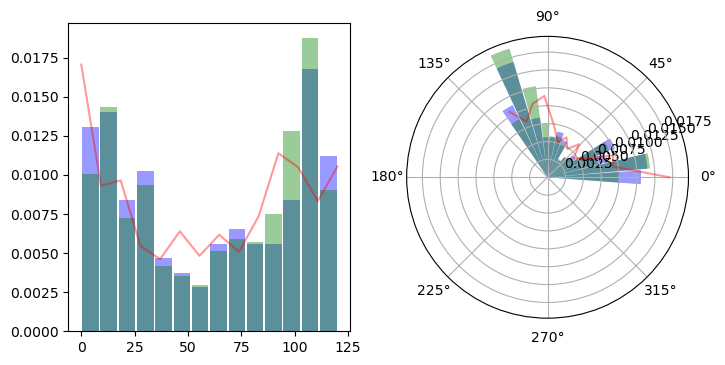

In [ ]:
bin_lim = 2/3*np.pi

df_all = all_pairs_df[all_pairs_df.fusion].copy()

for i in range(3):
    df_all["mp_angle"+str(i+1)]  = (df_all["angm"+str(i+1)] - df_all.angp1) #% (2*np.pi)

mp_ang = []
for i in range(3):
    mp_ang.append(df_all["mp_angle"+str(i+1)].values)

mp_ang = np.array(mp_ang) % (2*np.pi)

df_all["mp_angle_av"] = circmean(mp_ang, axis=0, high=2/3*np.pi)

df_all["mp_angle_av_by_id"] = df_all.groupby(['min_id'])['mp_angle_av'].transform(lambda x: circmean(x, high=2/3*np.pi))



bins_number = 45
bins_num_norm = int(bins_number * bin_lim / (2*np.pi))   # the [0, 360) interval will be subdivided into this

bins = np.linspace(0, bin_lim, bins_num_norm+1) #* 180/np.pi
bins_ = np.linspace(0, bin_lim, bins_num_norm) #* 180/np.pi
width = bin_lim / bins_num_norm

fig1 = plt.figure(figsize=(8,4))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')

p1,_,_ = ax1.hist(df_all.groupby(['min_id'])['mp_angle_av'].apply(lambda x: circmean(x, high=2/3*np.pi)) * 180/np.pi, bins*180/np.pi, # 3 paeks
    alpha=.4, rwidth=.9, density=True, color="b")
ax2.bar(bins_, p1, color="b", width=width, bottom=0.0, alpha=.4)

p1,_,_ = ax1.hist(df_all.mp_angle_av_by_id * 180/np.pi, bins*180/np.pi, # 3 paeks
    alpha=.4, rwidth=.9, density=True, color="g")
ax2.bar(bins_, p1, color="g", width=width, bottom=0.0, alpha=.4)

p1,_,_ = ax1.hist(mp_ang.ravel() * 180/np.pi, bins*180/np.pi, # 3 paeks
    alpha=.0, rwidth=.9, density=True, color="r")
ax1.plot(bins_ * 180/np.pi, p1, color="r", alpha=.4)
ax2.plot(bins_, p1, color="r", alpha=.4)

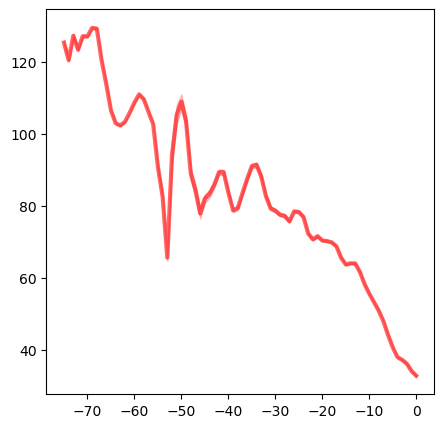

In [ ]:
fig, ax1 = plt.subplots(1,1,  figsize=(5,5))
show = True
win = 1

df_all = all_pairs_df[all_pairs_df.fusion].copy()

df = df_all[~df_all.fusion].reset_index()
df["track_frame"] = df.groupby(['min_id'])['FRAME'].transform(lambda x: x-x.iloc[0])
df_av_up = plot_rolling_average(df, ax1, "distance", "track_frame", win=win, color="b", avfunc=np.mean, stdfunc=np.std)


df = df_all[df_all.fusion].reset_index()
df["track_frame"] = df.groupby(['min_id'])['FRAME'].transform(lambda x: x-x.iloc[-1])
df_av_up = plot_rolling_average(df, ax1, "distance", "track_frame", win=win, color="r", avfunc=np.mean, stdfunc=np.std)


# ax2 = ax1.twinx()


# df_av_up = plot_rolling_average(df[(df.mp_angle_av_by_id>(40/180*np.pi))&(df.mp_angle_av_by_id<(80/180*np.pi))], ax1, "distance", "track_frame", win=win, color="m", avfunc=np.mean, stdfunc=np.std)
# df_av_up = plot_rolling_average(df[(df.mp_angle_av_by_id>(80/180*np.pi))], ax1, "distance", "track_frame", win=win, color="k", avfunc=np.mean, stdfunc=np.std)
# df_av_up = plot_rolling_average(df[(df.mp_angle_av_by_id<(40/180*np.pi))], ax1, "distance", "track_frame", win=win, color="r", avfunc=np.mean, stdfunc=np.std)

# df_av_up = plot_rolling_average(df[df.fuse_up], ax1, "distance", "track_frame", win=win, color="g", avfunc=np.mean, stdfunc=np.std)
# df_av_up = plot_rolling_average(df[~df.fuse_up], ax1, "distance", "track_frame", win=win, color="b", avfunc=np.mean, stdfunc=np.std)
# df_av_up = plot_rolling_average(df[~df.fuse_up], ax2, "mp_angle_av", "track_frame", win=win, color="g", low=-1/3*np.pi, high=1/3*np.pi)
# colors = ["r","b","r","b"]
# for i, dfi in enumerate((df[df.fuse_up], df[~df.fuse_up])):
#     df_dist = plot_rolling_average(dfi, ax1, "distance", "track_frame", show=show, win=win, color="r", avfunc=np.mean, stdfunc=np.std)
#     df_ang = plot_rolling_average(dfi, ax2, "mp_angle_av", "track_frame", show=show, win=win, color="b", low=-1/3*np.pi, high=1/3*np.pi)
# ax1.set_xlim([-100,20])  


In [ ]:
len(fuse_df.plus_id[fuse_df.fusion].unique()), len(fuse_df.plus_id[~fuse_df.fusion].unique())

NameError: name 'fuse_df' is not defined

In [ ]:
tt

NameError: name 'tt' is not defined

<BarContainer object of 35 artists>

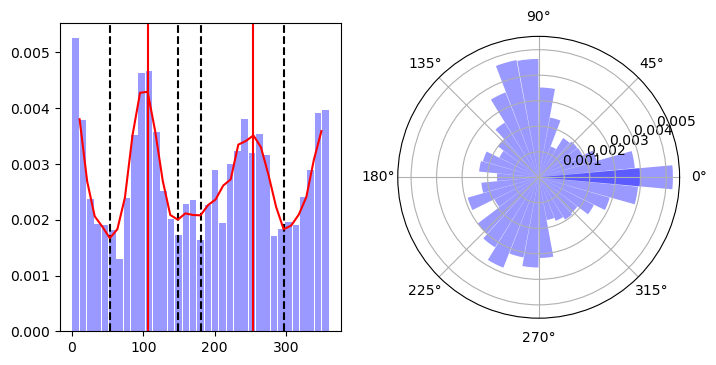

In [ ]:
from scipy.signal import find_peaks, argrelextrema

fig1 = plt.figure(figsize=(8,4))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')
bins_number = 35  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2*np.pi, bins_number+1) #* 180/np.pi
bins_ = np.linspace(0, 2*np.pi, bins_number) #* 180/np.pi
width = 2 * np.pi / bins_number

h = ax1.hist(mp_ang_up.ravel() *180/np.pi, bins*180/np.pi, # 3 paeks
# p1,_,_ = ax1.hist(fuse_df["mp_angle_av"][fuse_df.fuse_up] *180/np.pi, bins*180/np.pi, # one peak
    alpha=.4, rwidth=.9, density=True, color="b")

values = h[1][:-1] + np.diff(h[1])[0] / 2
# ax1.plot(bins_ *180/np.pi, h[0], "-r")

norm_density = h[0] #/ h[0].sum()
norm_density_ma = pd.Series(norm_density).rolling(bins_number//9, center=True).mean().values

peaks = find_peaks(norm_density_ma, distance=6)[0]
minimas = argrelextrema(norm_density_ma, np.less)[0]

for peak in peaks:
    ax1.axvline(bins_[peak] *180/np.pi, color='r')
for min in minimas:    
    ax1.axvline(bins_[min] *180/np.pi, color='k', ls='--')

ax1.plot(bins_ *180/np.pi, norm_density_ma, "-r")
# ax1.plot(bins_ *180/np.pi, norm_density, "-r")


ax2.bar(bins_, h[0], color="b", width=width, bottom=0.0, alpha=.4)

In [ ]:
(bins_[peaks] *180/np.pi ) % 120

array([95.29411765, 38.82352941, 24.70588235])

Text(0, 0.5, '$Angle ~(deg)$')

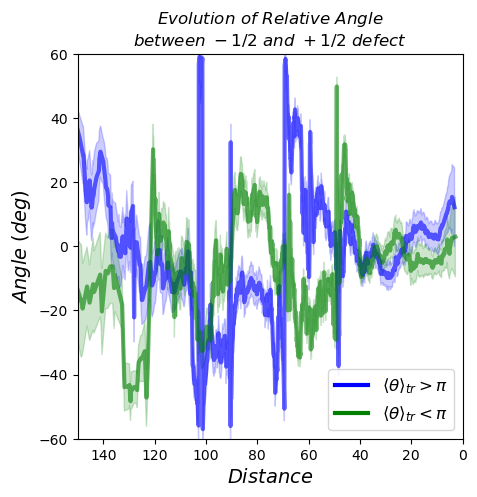

In [ ]:
fig, ax1 = plt.subplots(1,1,  figsize=(5,5))

df_all = all_pairs_df[all_pairs_df.creation].copy()

mp_ang = []
mp_ang_up = []
mp_ang_down = []
for i in range(3):
    mp_ang.append(df_all["mp_angle"+str(i+1)].values)
    # mp_ang_up.append(df_all["mp_angle"+str(i+1)].values)
    mp_ang_up.append(df_all["mp_angle"+str(i+1)][df_all.fuse_up].values)
    mp_ang_down.append(df_all["mp_angle"+str(i+1)][~df_all.fuse_up].values)   

mp_ang_up = np.array(mp_ang_up) #% (2/3*np.pi)
mp_ang_down = np.array(mp_ang_down) #% (2/3*np.pi)
df_all["mp_angle_av"] = circmean(mp_ang, axis=0, low=0., high=2/3*np.pi)

win = 3
# for i in range(3):
    # df_av_up = plot_rolling_average(fuse_df[fuse_df.fuse_up], ax1, "mp_angle"+str(i+1), "distance", win=win, color="b", low=-2/3*np.pi, high=0)
    # df_av_up = plot_rolling_average(fuse_df[~fuse_df.fuse_up], ax1, "mp_angle"+str(i+1), "distance", win=win, color="g", low=0*np.pi, high=2/3*np.pi)


# ax1.plot(df_all.distance[fuse_df.fuse_up], (df_all.mp_angle_av[fuse_df.fuse_up] % (2/3*np.pi) - (1/3*np.pi))*180/np.pi, "ob", alpha=.05)
# ax1.plot(df_all.distance[~fuse_df.fuse_up], (df_all.mp_angle_av[~fuse_df.fuse_up] % (2/3*np.pi) - (1/3*np.pi))*180/np.pi, "og", alpha=.05)

# df_av_up = plot_rolling_average(df_all, ax1, "mp_angle_av", "distance", win=win, color="k", low=-1/3*np.pi, high=1/3*np.pi)
df_av_up = plot_rolling_average(df_all[df_all.fuse_up], ax1, "mp_angle_av", "distance", win=win, color="b", low=-1/3*np.pi, high=1/3*np.pi)
df_av_up = plot_rolling_average(df_all[~df_all.fuse_up], ax1, "mp_angle_av", "distance", win=win, color="g", low=-1/3*np.pi, high=1/3*np.pi)

# ax1.plot([0,0],[0,0], "-r", linewidth=3, label=r"$all$")
ax1.plot([0,0],[0,0], "-b", linewidth=3, label=r"$\langle \theta \rangle _{tr} > \pi$")
ax1.plot([0,0],[0,0], "-g", linewidth=3, label=r"$\langle \theta \rangle _{tr} < \pi$")


plt.xlim([150,0]); plt.ylim([-60, 60]); #plt.yticks(np.arange(0, 121, 30))
plt.gca().set_box_aspect(1); #plt.gca().invert_xaxis()  
plt.legend(fontsize=12); 
plt.title(r"$Evolution ~of ~Relative ~Angle$" +"\n" + r"$between ~-1/2 ~and ~+1/2 ~defect$")
plt.xlabel(r"$Distance$", fontsize=14); plt.ylabel(r"$Angle ~(deg)$", fontsize=14)    

In [ ]:
df = fuse_df.reset_index()
df["track_frame"] = 0
for p_id in df.min_id.unique():
    df.track_frame[df.min_id==p_id] = df.FRAME[df.min_id==p_id]-df.FRAME[df.min_id==p_id].iloc[-1]

array([[<AxesSubplot: title={'center': 'mp_angle1'}>,
        <AxesSubplot: title={'center': 'mp_angle2'}>],
       [<AxesSubplot: title={'center': 'mp_angle3'}>,
        <AxesSubplot: title={'center': 'mp_angle_av'}>]], dtype=object)

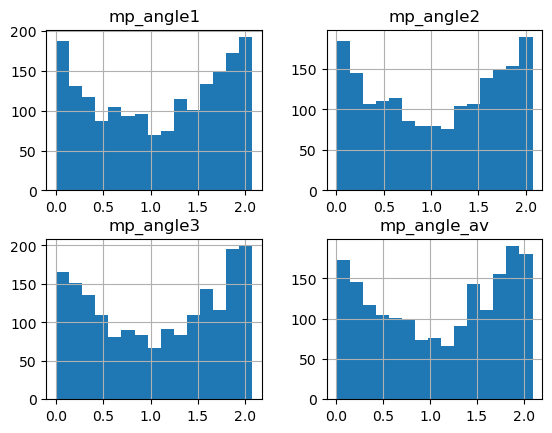

In [ ]:
(df[["mp_angle1","mp_angle2","mp_angle3","mp_angle_av"]][df.fuse_up] % (2/3*np.pi)).hist(bins=15)

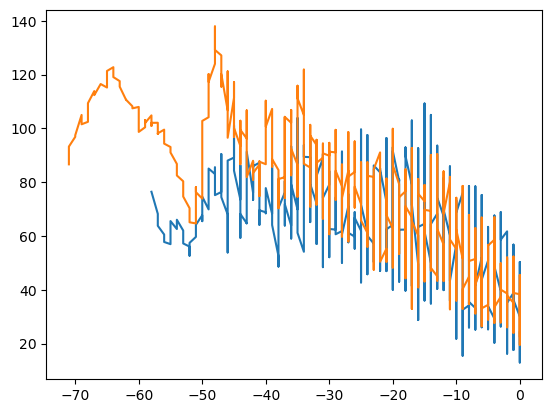

In [ ]:
ddf = df[df.fuse_up].sort_values(by="track_frame")
dist = ddf.distance.rolling(5).mean()
plt.plot(ddf.track_frame, dist)

ddf = df[~df.fuse_up].sort_values(by="track_frame")
dist = ddf.distance.rolling(10).mean()
plt.plot(ddf.track_frame, dist)

Text(0, 0.5, '$Angle ~(deg)$')

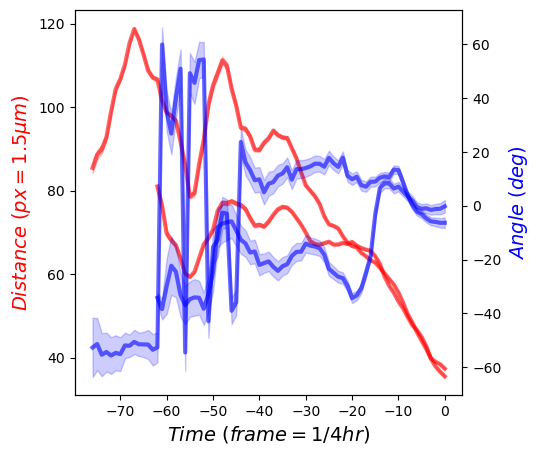

In [ ]:
fig, ax1 = plt.subplots(1,1,  figsize=(5,5))
ax2 = ax1.twinx()

show = True
win = 3
# df_av_up = plot_rolling_average(df[df.fuse_up], ax2, "mp_angle_av", "track_frame", win=win, color="b", low=-1/3*np.pi, high=1/3*np.pi)
# df_av_up = plot_rolling_average(df[~df.fuse_up], ax2, "mp_angle_av", "track_frame", win=win, color="g", low=-1/3*np.pi, high=1/3*np.pi)
colors = ["r","b","r","b"]
for i, dfi in enumerate((df[df.fuse_up], df[~df.fuse_up])):
    df_dist = plot_rolling_average(dfi, ax1, "distance", "track_frame", show=show, win=win, color="r", avfunc=np.mean, stdfunc=np.std)
    df_ang = plot_rolling_average(dfi, ax2, "mp_angle_av", "track_frame", show=show, win=win, color="b", low=-1/3*np.pi, high=1/3*np.pi)

    if not show:
        ax1.plot(df_dist.track_frame, df_dist.distance_ave, "r", linewidth=3, alpha=.6)
        ax1.fill_between(df_dist.track_frame, 
                        df_dist.distance_ave - df_dist.distance_std,
                        df_dist.distance_ave + df_dist.distance_std,
                        color="r", alpha=.2)
        ax2.plot(df_ang.track_frame, df_ang.mp_angle_av_ave, "b", linewidth=3, alpha=.6)
        ax2.fill_between(df_ang.track_frame, 
                        df_ang.mp_angle_av_ave - df_ang.mp_angle_av_std,
                        df_ang.mp_angle_av_ave + df_ang.mp_angle_av_std,
                        color="b", alpha=.2)
    # break

# ax1.set_xlim([-60,0])    
# ax1.set_ylim([0,200]); 
# ax2.set_ylim([-10,60])
ax1.set_xlabel(r"$Time ~(frame=1/4hr)$", fontsize=14)
ax1.set_ylabel(r"$Distance ~(px=1.5 \mu m)$", fontsize=14, color="red")
ax2.set_ylabel(r"$Angle ~(deg)$", fontsize=14, color="blue") 

In [ ]:
stop_here

NameError: name 'stop_here' is not defined

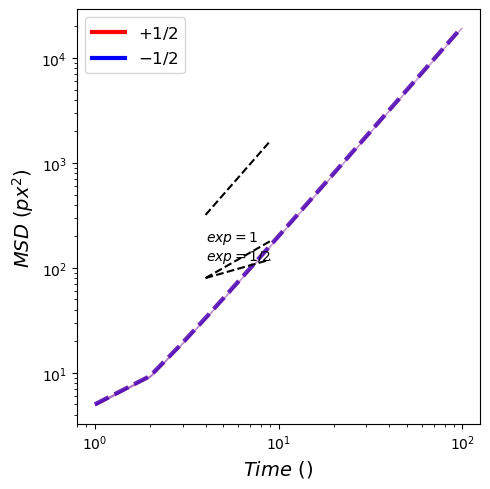

In [ ]:
msds = []
for i in range(100):
    t_ = np.arange(0,1e2,1)
    x_ = i + t_ 
    y_ = i +  t_
    id = i

    msds.append(pd.DataFrame({"FRAME": t_, 'X':x_, 'Y':y_, "id": id})) 

df = pd.concat(msds)

df_msd = msd_from_df(df,"X","Y","FRAME","id")

fig, ax1 = plt.subplots(1,1, figsize=(5,5))
# msd_plus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="b", alpha=.05)
# msd_minus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="g", alpha=.05)

win = 1

dfs = [df_msd, df_msd]
colors = ["--r","--b", "-r", "-b"]

for msd_df,color in zip(dfs, colors):
    msd_df = msd_df.sort_values(by="FRAME")
    msd_df["ave"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.mean)
    msd_df["std"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.std)
    msd_df["count"] = roll_func(msd_df.MSD, msd_df.FRAME, win, np.sum)

    ax1.plot(msd_df.FRAME, msd_df["ave"], color, alpha=.6, linewidth=3)
    ax1.fill_between(msd_df.FRAME, 
                    msd_df["ave"]-msd_df["std"]/msd_df["count"]**.5, 
                    msd_df["ave"]+msd_df["std"]/msd_df["count"]**.5, 
                    color=''.join(x for x in color if x.isalpha()), alpha=.2) 


ax1.plot([0,0],[0,0], "-", color="r", linewidth=3, label=r"$+1/2$")
ax1.plot([0,0],[0,0], "-", color="b", linewidth=3, label=r"$-1/2$")
xref = np.arange(4, 10, 1)
ax1.plot(xref, 4e1*xref**.5, "--k", xref, 2e1*xref**1,"--k", xref, 2e1*xref**2,"--k")
ax1.text(xref[0], 4e1*xref[-1]**.5, r"$exp=1/2$", )
ax1.text(xref[0], 2e1*xref[-1]**1, r"$exp=1$")
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel(r"$Time ~()$", fontsize=14); ax1.set_ylabel(r"$MSD ~(px^2)$", fontsize=14)
plt.legend(loc='upper left', fontsize=12); plt.tight_layout()


1
1


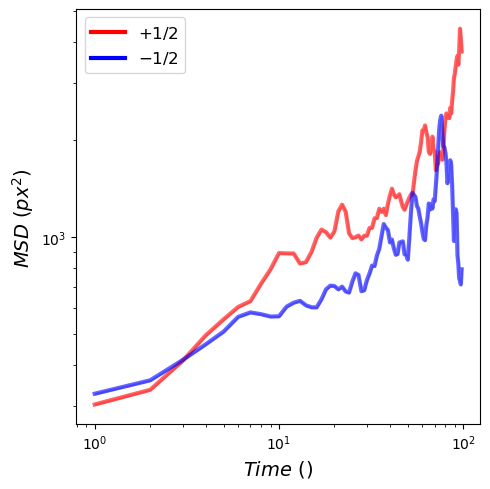

In [75]:
%matplotlib inline

# dist = 60
# msd_plus_df_far = msd_from_df(all_pairs_df[all_pairs_df.distance>dist].reset_index(),"xp","yp","FRAME","plus_id")
# msd_minus_df_far = msd_from_df(all_pairs_df[all_pairs_df.distance>dist].reset_index(),"xm","ym","FRAME","min_id")
# msd_plus_df_close = msd_from_df(all_pairs_df[all_pairs_df.distance<dist].reset_index(),"xp","yp","FRAME","plus_id")
# msd_minus_df_close= msd_from_df(all_pairs_df[all_pairs_df.distance<dist].reset_index(),"xm","ym","FRAME","min_id")

msd_plus_df_far = msd_from_df(all_pairs_df.reset_index(),"xp","yp","FRAME","plus_id")
msd_minus_df_far = msd_from_df(all_pairs_df.reset_index(),"xm","ym","FRAME","min_id")

fig, ax1 = plt.subplots(1,1, figsize=(5,5))
# msd_plus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="b", alpha=.05)
# msd_minus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="g", alpha=.05)

win = 1

dfs = [msd_plus_df_far, msd_minus_df_far, ]#, msd_plus_df_close, msd_minus_df_close]
# dfs = [msd_plus_df_close, msd_minus_df_close]
colors = ["r","b", "-r", "-b"]

for msd_df,color in zip(dfs, colors):
    # msd_df = msd_df.sort_values(by="FRAME")
    # msd_df["ave"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.mean)
    # msd_df["std"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.std)
    # msd_df["count"] = roll_func(msd_df.MSD, msd_df.FRAME, win, np.sum)

    # ax1.plot(msd_df.FRAME, msd_df["ave"], color, alpha=.6, linewidth=3)
    # ax1.fill_between(msd_df.FRAME, 
    #                 msd_df["ave"]-msd_df["std"]/msd_df["count"]**.5, 
    #                 msd_df["ave"]+msd_df["std"]/msd_df["count"]**.5, 
    #                 color=''.join(x for x in color if x.isalpha()), alpha=.2) 
    df = plot_rolling_average(msd_df, ax1, "MSD", "FRAME", win=win, color=color, avfunc=np.mean, stdfunc=np.std)
    print(df.FRAME.min())

ax1.plot([0,0],[0,0], "-", color="r", linewidth=3, label=r"$+1/2$")
ax1.plot([0,0],[0,0], "-", color="b", linewidth=3, label=r"$-1/2$")
xref = np.arange(df.FRAME.mean()-6, df.FRAME.mean()+3, 1)
# ax1.text(xref[0], df.MSD_ave.min()*xref[-3]**1, r"$exp=1$")
# ax1.text(xref[0], df.MSD_ave.min()*xref[-3]**2, r"$exp=2$", )
# ax1.plot(xref, df.MSD_ave.min()*xref**2, "--k", xref, df.MSD_ave.min()*xref**1,"--k")
ax1.set_xscale('log'); ax1.set_yscale('log')
ax1.set_xlabel(r"$Time ~()$", fontsize=14); ax1.set_ylabel(r"$MSD ~(px^2)$", fontsize=14)
plt.legend(loc='upper left', fontsize=12); plt.tight_layout()

fig.savefig(r"C:\Users\victo\OneDrive - BGU\Presentations\Images\HBEC C2C12.svg")


In [47]:
df.MSD_ave.min(), 2e2*xref[-1]**1

(14630.905386159426, 2845.986984815618)

In [17]:
%matplotlib qt
# msd_df = msd_from_df(all_pairs_df.reset_index(),"xp","yp","FRAME","plus_id")

def msd(x,y):
    return np.cumsum(np.diff(x))**2 + np.cumsum(np.diff(y))**2

df = all_pairs_df.reset_index()

xlabel,ylabel,tlabel,id_label  = "xm","ym","FRAME","min_id"
xlabel,ylabel,tlabel,id_label  = "xp","yp","FRAME","plus_id"

msds = []
for id in df[id_label].unique():
    idx = (df[id_label]==id)
    df_ = df[idx].copy()
    if id==101:
        break
    if idx.sum()>3:
        t = df_[tlabel].to_numpy()        
        # t = t[1:] - t[0]               
        x = df_[xlabel].to_numpy()
        y = df_[ylabel].to_numpy()
        id_l = df_[id_label].to_numpy()
        msds.append(pd.DataFrame({'FRAME': t[1:] - t[0], 
                                  'MSD':msd(x,y),
                                  'ID': id_l[1:]
                                  }).dropna())            
ddf = pd.concat(msds)
msd_df = ddf[ddf["FRAME"]>=0].copy()
msd_df = msd_df.sort_values(by="FRAME")
msd_df["ave"] = roll_func(msd_df.MSD, msd_df.FRAME, 3, func=np.mean)
plt.plot(msd_df.FRAME, msd_df["ave"],"-o", alpha=.6, linewidth=3)
# plt.xscale('log'); plt.yscale('log'); 
plt.gca().set_box_aspect(1)

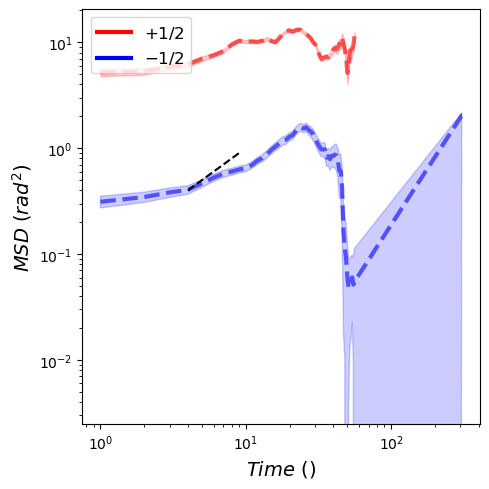

In [18]:
%matplotlib inline
dist = DIST
# msd_plus_df_far = msd_from_df(all_pairs_df[all_pairs_df.distance>dist].reset_index(),"xp","yp","FRAME","plus_id")
# msd_minus_df_far = msd_from_df(all_pairs_df[all_pairs_df.distance>dist].reset_index(),"xm","ym","FRAME","min_id")
# msd_plus_df_close = msd_from_df(all_pairs_df[all_pairs_df.distance<dist].reset_index(),"xp","yp","FRAME","plus_id")
# msd_minus_df_close= msd_from_df(all_pairs_df[all_pairs_df.distance<dist].reset_index(),"xm","ym","FRAME","min_id")

# msd_plus_df_far = msd_from_df(all_pairs_df.reset_index(),"xp","yp","FRAME","plus_id")
# msd_minus_df_far = msd_from_df(all_pairs_df.reset_index(),"xm","ym","FRAME","min_id")
msd_plus_df_far = ang_msd_from_df(all_pairs_df.reset_index(),
                              "angp1","FRAME","plus_id", minimal_track=20)

msd_minus_df_far = ang_msd_from_df(all_pairs_df.reset_index(),
                               "angm1","FRAME","min_id",period=2/3*np.pi)



%matplotlib inline
fig, ax1 = plt.subplots(1,1, figsize=(5,5))
# msd_plus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="b", alpha=.05)
# msd_minus_df.plot.scatter("FRAME", "MSD", logx=True, logy=True, ax=ax1, c="g", alpha=.05)

win = 3

dfs = [msd_plus_df_far, msd_minus_df_far]#, msd_plus_df_close, msd_minus_df_close]
# dfs = [msd_plus_df_close, msd_minus_df_close]
colors = ["--r","--b", "-r", "-b"]

for msd_df,color in zip(dfs, colors):
    msd_df = msd_df.sort_values(by="FRAME")
    msd_df["ave"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.mean)
    msd_df["std"] = roll_func(msd_df.MSD, msd_df.FRAME, win, func=np.std)
    msd_df["count"] = roll_func(msd_df.MSD, msd_df.FRAME, win, np.sum)

    ax1.plot(msd_df.FRAME, msd_df["ave"], color, alpha=.6, linewidth=3)
    ax1.fill_between(msd_df.FRAME, 
                    msd_df["ave"]-msd_df["std"]/msd_df["count"]**.5, 
                    msd_df["ave"]+msd_df["std"]/msd_df["count"]**.5, 
                    color=''.join(x for x in color if x.isalpha()), alpha=.2) 


ax1.plot([0,0],[0,0], "-", color="r", linewidth=3, label=r"$+1/2$")
ax1.plot([0,0],[0,0], "-", color="b", linewidth=3, label=r"$-1/2$")
xref = np.arange(4, 10, 1)
ax1.plot(xref, 1e-1*xref**1,"--k")
# ax1.text(xref[0], 4e2*xref[-1]**.5, r"$exp=1/2$", )
# ax1.text(xref[0], 2e2*xref[-1]**1, r"$exp=1$")
ax1.set_xscale('log'); ax1.set_yscale('log'); #ax1.set_ylim([1e-2,2e0])
ax1.set_xlabel(r"$Time ~()$", fontsize=14); ax1.set_ylabel(r"$MSD ~(rad^2)$", fontsize=14)
plt.legend(loc='upper left', fontsize=12); plt.tight_layout()


## End of Pairs

## Pair vs. Nonpair

<BarContainer object of 45 artists>

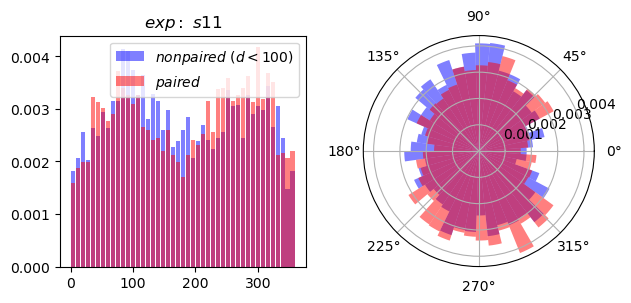

In [ ]:
%matplotlib inline
dist_tresh = 100
SAVE = False
bins_number = 45  # the [0, 360) interval will be subdivided into this
# number of equal bins
bins = np.linspace(0, 2*np.pi, bins_number+1)
nonpair_ang = df["p_ang_rel"][
    np.logical_and(~df["pair"], df["distance"]<dist_tresh)
    ] % (2*np.pi)
pair_ang_up = df["p_ang_rel"][(df["pair"])] % (2*np.pi)
pair_ang_down = df["p_ang_rel"][(df["pair"])&(~df["fuse_up"])] % (2*np.pi)

fig3 = plt.figure(figsize=(7,3))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')

ax1.set_title(r"$exp: ~%s $" % experiment)
nonpair, _, _ =  ax1.hist(nonpair_ang*180/np.pi, bins*180/np.pi, density=True, 
    rwidth=.9, alpha=.5, color="blue", label="$nonpaired ~(d<%s)$" % dist_tresh)
pair_up, _, _ =  ax1.hist(pair_ang_up*180/np.pi, bins*180/np.pi, density=True, 
    rwidth=.9, alpha=.5, color="red", label="$paired$")
# pair_down, _, _ =  ax1.hist(pair_ang_down*180/np.pi, bins*180/np.pi, density=True, 
#     rwidth=.9, alpha=.5, color="g", label="$pair ~up$")    

ax1.legend(loc='upper right')

width = 2 * np.pi / bins_number
ax2.bar(bins[:bins_number], nonpair, color="blue",width=width, bottom=0.0, alpha=.5)
ax2.bar(bins[:bins_number], pair_up, color="red",width=width, bottom=0.0, alpha=.5)
# ax2.bar(bins[:bins_number], pair_down, color="g",width=width, bottom=0.0, alpha=.5)
# if SAVE:
#     fig3.savefig(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_\Images/pair-nonpair_ang_distribution_hist_" + experiment +".png")


In [ ]:
radius = 200
neighbour_dist = []
for frame in plus_minus_df["FRAME"].unique()[:]:
    p_idx = np.logical_and(plus_minus_df["FRAME"]==frame, plus_minus_df["charge"]==.5)
    m_idx = np.logical_and(plus_minus_df["FRAME"]==frame, plus_minus_df["charge"]==-.5)
    plus_xy = plus_minus_df[["TRACK_ID","x_img1","y_img1","ang1"]][p_idx]
    minus_xy = plus_minus_df[["TRACK_ID","x_img1","y_img1","ang1","ang2","ang3"]][m_idx]

    tree = KDTree(plus_xy[["x_img1","y_img1"]]) #map all +1/2 defects

    # for each -1/2 map distances to +1/2 neighbours in RADIUS
    for index, row in minus_xy.iterrows():
        # find +1/2 defects within radius (r=maximal_pair_distance)
        ind, dist = tree.query_radius(np.array(row[['x_img1','y_img1']]).reshape(1, -1), 
                                      r=radius, return_distance=True, sort_results=True)
        # find [-1/2, +1/2] pair TRACK_IDs
        try:
            plus_neighbours = plus_xy.iloc[ind[0]].copy()
            plus_neighbours["DIST"] = dist[0]
            plus_pair_id = pairs_df["plus"][pairs_df["minus"]==row["TRACK_ID"]].values[0]
            plus_neighbours["PAIR"] = (plus_neighbours["TRACK_ID"] == plus_pair_id)
            plus_neighbours["mTRACK_ID"] = row["TRACK_ID"]

            plus_neighbours["mp_ang"] = np.arctan2(
                row['y_img1']-plus_neighbours["y_img1"], 
                row['x_img1']-plus_neighbours["x_img1"]
                ) % (2*np.pi)

            plus_neighbours["p_ang_rel"] = (plus_neighbours["ang1"] - plus_neighbours["mp_ang"]) % (2*np.pi)

            plus_neighbours["delta_ang1"] = (row["ang1"] - plus_neighbours["ang1"])
            plus_neighbours["delta_ang2"] = (row["ang2"] - plus_neighbours["ang1"])
            plus_neighbours["delta_ang3"] = (row["ang3"] - plus_neighbours["ang1"])

            plus_neighbours["p_ang"] = plus_neighbours["ang1"]
            plus_neighbours["px_img1"] = plus_neighbours["x_img1"]
            plus_neighbours["py_img1"] = plus_neighbours["y_img1"]
            
            plus_neighbours["mx_img1"] = row["x_img1"]
            plus_neighbours["my_img1"] = row["y_img1"]
            plus_neighbours["m_ang1"] = row["ang1"]
            plus_neighbours["m_ang2"] = row["ang2"]
            plus_neighbours["m_ang3"] = row["ang3"]

            neighbour_dist.append(plus_neighbours[[
                "PAIR","DIST","p_ang_rel", "TRACK_ID", 
                "delta_ang1","delta_ang2","delta_ang3",
                "p_ang", "px_img1", "py_img1",
                "mx_img1", "my_img1",
                "m_ang1", "m_ang2", "m_ang3", "mTRACK_ID"
                ]])
        except:
            pass

    #     break
neighbour_dist = pd.concat(neighbour_dist).dropna()
# grouped = neighbour_dist.groupby('TRACK_ID')["p_ang_rel"]
# neighbour_dist["fuse_up"] = grouped.transform(lambda x: circmean(x)>np.pi).astype('bool')

neighbour_dist["mp_angle"] = np.arctan2(neighbour_dist["my_img1"]-neighbour_dist["py_img1"], 
                                      neighbour_dist["mx_img1"]-neighbour_dist["px_img1"]) % (2*np.pi)


neighbour_dist["angp1_rel"] = (neighbour_dist["p_ang"] - neighbour_dist["mp_angle"]) % (2*np.pi)

grouped = neighbour_dist.groupby('TRACK_ID')["angp1_rel"]
neighbour_dist["fuse_up"] = grouped.transform(lambda x: circmean(x)>np.pi)

Text(0.5, 1.0, '$Relative ~angle ~btw ~-1/2 ~and ~+1/2$')

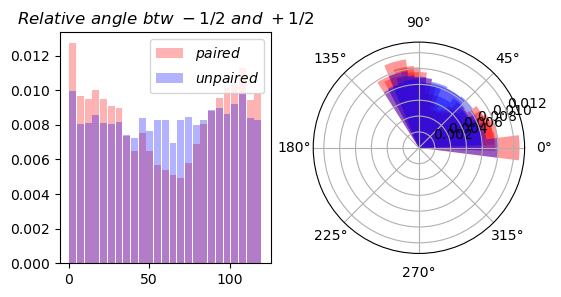

In [ ]:
%matplotlib inline
max_dist = 200
paired_up, paired_down, unpaired, delta = [], [], [], []
for i in range(3):
    paired_up.append(neighbour_dist["delta_ang"+str(i+1)]
        [(neighbour_dist["PAIR"])\
        &(neighbour_dist["DIST"]<max_dist)\
        &(neighbour_dist["DIST"]<max_dist)\
        ].values)
    unpaired.append(neighbour_dist["delta_ang"+str(i+1)]
        [(~neighbour_dist["PAIR"])&(neighbour_dist["DIST"]<max_dist)].values)

    # m_ang = neighbour_dist["m_ang"+str(i+1)][
    #         (neighbour_dist["PAIR"])&(neighbour_dist["DIST"]<120)].values
    # p_ang = neighbour_dist["p_ang"][
    #         (neighbour_dist["PAIR"])&(neighbour_dist["DIST"]<120)].values
    # delta.append(m_ang - p_ang)        

paired_up = np.concatenate(paired_up) % (2/3*np.pi)
unpaired = np.concatenate(unpaired) % (2/3*np.pi)
# delta = np.concatenate(delta) % (2/3*np.pi)

fig1 = plt.figure(figsize=(6,3))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')
bins_number = 25  # the [0, 360) interval will be subdivided into this
bins = np.linspace(0, 2/3*np.pi, bins_number+1)

p1,_,_ = ax1.hist(paired_up*180/np.pi, bins*180/np.pi, #one peak 
                    density=True, rwidth=.9, alpha=.3, color="red", label=r"$paired$")
p2,_,_ = ax1.hist(unpaired*180/np.pi, bins*180/np.pi, #one peak 
                    density=True, rwidth=.9, alpha=.3, color="blue", label=r"$unpaired$")
# p3,_,_ = ax1.hist(delta*180/np.pi, bins*180/np.pi, #one peak 
#                     density=True, rwidth=.9, alpha=.3, color="g", label=r"$unpaired$")

width = 2 * np.pi / bins_number
ax2.bar(bins[:bins_number], p1, color="red", width=width, bottom=0.0, alpha=.4)    
ax2.bar(bins[:bins_number], p2, color="blue", width=width, bottom=0.0, alpha=.4,)
# ax2.bar(bins[:bins_number], p3, color="g", width=width, bottom=0.0, alpha=.4,)  
ax1.legend(loc='upper right')    
ax1.set_title(r"$Relative ~angle ~btw ~-1/2 ~and ~+1/2$")                                  

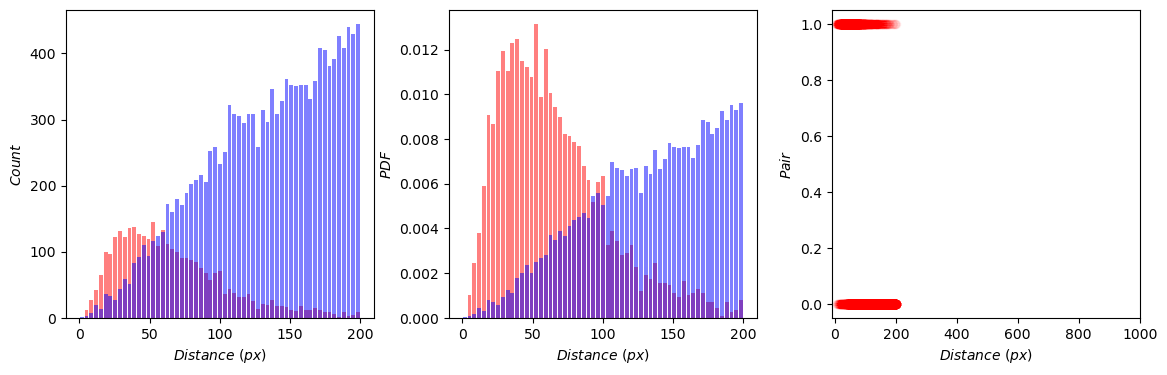

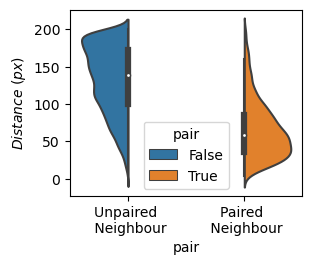

In [ ]:
%matplotlib inline
    #     'PAIR', 'DIST', 'p_ang_rel', 'TRACK_ID', 
    #     'delta_ang1', 'delta_ang2', 'delta_ang3', 
    #     'p_ang', 'px_img1', 'py_img1', 
    #     'mx_img1', 'my_img1', 'm_ang1', 'm_ang2', 'm_ang3', 
    #    'mTRACK_ID', 'mp_angle', 'angp1_rel',
    #    'fuse_up'
                
df = neighbour_dist.set_axis(['pair', 'distance', 'p_ang_rel', 'TRACK_ID', 
                                "delta_ang1","delta_ang2","delta_ang3", 
                                'p_ang', 'px_img1', 'py_img1', 
                    'mx_img1', 'my_img1', 'm_ang1', 'm_ang2', 'm_ang3', 
                    'mTRACK_ID', 'mp_angle', 'angp1_rel',
                    'fuse_up'
                            ], axis=1).dropna()

bins_number = 60
bins = np.linspace(0, radius, bins_number)
fig, (ax1,ax2, ax3) = plt.subplots(1,3, figsize=(14,4))
# p1 = ax1.hist(distance[pairs_idx], bins, density=False, rwidth=.8, alpha=.5, color="red")
# p2 = ax1.hist(distance[~pairs_idx], bins, density=False, rwidth=.8, alpha=.5, color="blue")
p1 = ax1.hist(df["distance"][df["pair"]], bins, density=False, rwidth=.8, alpha=.5, color="red")
p1 = ax1.hist(df["distance"][~df["pair"]], bins, density=False, rwidth=.8, alpha=.5, color="blue")
ax1.set_xlabel("$Distance ~(px)$")
ax1.set_ylabel("$Count$")
ax1.set_box_aspect(1)

# p1 = ax2.hist(distance[pairs_idx], bins, density=True, rwidth=.8, alpha=.5, color="red")
# p2 = ax2.hist(distance[~pairs_idx], bins, density=True, rwidth=.8, alpha=.5, color="blue")
p1 = ax2.hist(df["distance"][df["pair"]], bins, density=True, rwidth=.8, alpha=.5, color="red")
p1 = ax2.hist(df["distance"][~df["pair"]], bins, density=True, rwidth=.8, alpha=.5, color="blue")
ax2.set_xlabel("$Distance ~(px)$")
ax2.set_ylabel("$PDF$")
ax2.set_box_aspect(1)

ax3.plot(df["distance"],df["pair"], "or", alpha=.01)
ax3.set_xlabel("$Distance ~(px)$")
ax3.set_ylabel("$Pair$")
ax3.set_xlim([-10,1000])
ax3.set_box_aspect(1)

# sns.violinplot([distance[pairs_idx], distance[~pairs_idx]], ax=ax3, split=True)

fig, ax = plt.subplots(figsize=(3,3))
sns.violinplot(data=df, x="pair", y="distance", ax=ax, hue="pair", split=True)
# sns.stripplot(data=df, x="pair", y="distance", ax=ax, marker=".", alpha=.01)
ax.set_xticklabels(["Unpaired \n Neighbour", "Paired \n Neighbour",])
ax.set_ylabel("$Distance ~(px)$")
ax.set_box_aspect(.8)

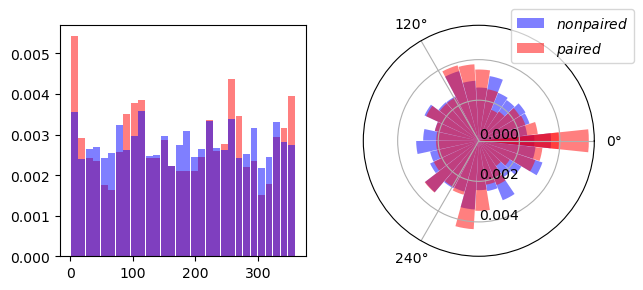

In [ ]:
for i in range(3):
    df["mp_angle"+str(i+1)]  = (df["m_ang"+str(i+1)] - df.p_ang) % (2*np.pi)

mp_ang_pairs = []
mp_ang_nonpairs = []
for i in range(3):
    mp_ang_pairs.append(df["mp_angle"+str(i+1)][df.pair])
    mp_ang_nonpairs.append(df["mp_angle"+str(i+1)][~df.pair])#
mp_ang_pairs = np.concatenate(mp_ang_pairs) % (2*np.pi)  
mp_ang_nonpairs = np.concatenate(mp_ang_nonpairs) % (2*np.pi)   

bins_number = 30
bins = np.linspace(0, 2*np.pi, bins_number+1)
bins_ = np.linspace(0, 2*np.pi, bins_number)
width = 2 * np.pi / bins_number

fig3 = plt.figure(figsize=(7,3))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')

pair, _, _ =  ax1.hist(mp_ang_pairs *180/np.pi, bins*180/np.pi, density=True, 
    rwidth=.9, alpha=.5, color="red", label="$nonpaired ~(d<%s)$")
nonpair, _, _ =  ax1.hist(mp_ang_nonpairs *180/np.pi, bins*180/np.pi, density=True, 
    rwidth=.9, alpha=.5, color="blue")

ax2.bar(bins_, nonpair, color="blue",width=width, bottom=0.0, alpha=.5, label="$nonpaired$")
ax2.bar(bins_, pair, color="red",width=width, bottom=0.0, alpha=.5, label="$paired$")


# ax2.fill_between(bins_, nonpair, color="blue", alpha=.5)
# ax2.fill_between(bins_, pair, color="red", alpha=.5)
ax2.set_rgrids(np.arange(0,.006,.002), angle=270); ax2.set_thetagrids([0,120, 240])
ax2.legend(bbox_to_anchor=(1.2, 1.1))

<AxesSubplot: xlabel='mp_angle', ylabel='distance'>

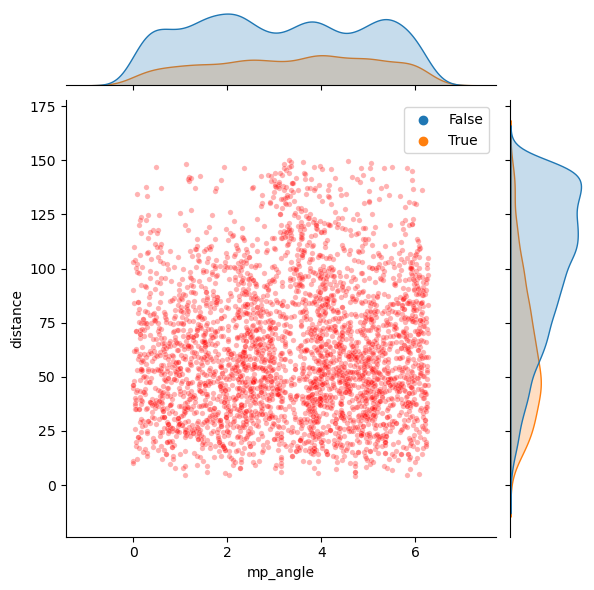

In [ ]:
nonpair_ang = df[["mp_angle", "distance","pair"]][
    # np.logical_and(df["pair"]==1, df["distance"]<200)
    df["distance"]<150#df["distance"][df["pair"]==1].max()
    ]
nonpair_ang["mp_angle"] = nonpair_ang["mp_angle"] % (2*np.pi)
g = sns.jointplot(data=nonpair_ang, x="mp_angle", y="distance", 
     hue="pair", alpha=.0, marker=".",)

sns.scatterplot(x=nonpair_ang["mp_angle"][nonpair_ang["pair"]==0], 
    y=nonpair_ang["distance"][nonpair_ang["pair"]==0], 
    s=0, color="blue", ax=g.ax_joint, alpha=.2)   

sns.scatterplot(x=nonpair_ang["mp_angle"][nonpair_ang["pair"]==1], 
    y=nonpair_ang["distance"][nonpair_ang["pair"]==1], 
    s=15, color="red", ax=g.ax_joint, alpha=.3) 

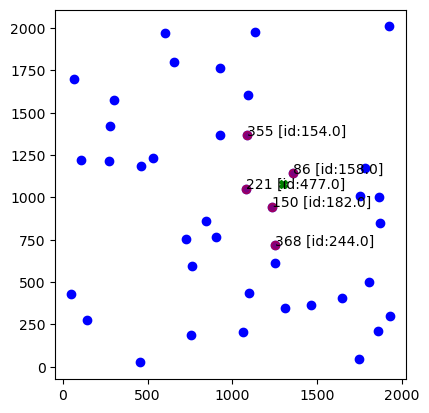

In [ ]:
%matplotlib inline
plt.plot(row['x_img1'], row['y_img1'], "Xg")
plt.plot(plus_xy["x_img1"], plus_xy["y_img1"], "ob")
plt.plot(plus_xy["x_img1"].iloc[ind[0]], plus_xy["y_img1"].iloc[ind[0]], "or", alpha=.5)
for ii,dd in zip(ind[0],dist[0]):
    plt.text(plus_xy["x_img1"].iloc[ii], plus_xy["y_img1"].iloc[ii],
        "%2d [id:%s]" % (dd, plus_xy["TRACK_ID"].iloc[ii])
        )

plt.gca().set_aspect(1)

## End Pair vs. Nonpair

In [ ]:
# experiment = "s11"
# plus_minus_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusAndMinusTM.csv").dropna(subset=['TRACK_ID'])
# plus_minus_df.TRACK_ID += (int(experiment.replace('s', ''))*1e6) # add expriment number as number of millions [1e6, 10e6, 11e6]

# pairs = []

# for frame in plus_minus_df["FRAME"].unique()[:]:
#     # print(frame)
#     p_idx = np.logical_and(plus_minus_df["FRAME"]==frame, plus_minus_df["charge"]==.5)
#     m_idx = np.logical_and(plus_minus_df["FRAME"]==frame, plus_minus_df["charge"]==-.5)
#     plus_xy = plus_minus_df[["TRACK_ID","x_img1","y_img1","ang1"]][p_idx]
#     minus_xy = plus_minus_df[["TRACK_ID","x_img1","y_img1","ang1","ang2","ang3"]][m_idx]

#     dist, idx = center_pairs(minus_xy[["x_img1","y_img1"]], plus_xy[["x_img1","y_img1"]])
#     # set a distance that define that defects are a pair (50)
#     dist_tresh = dist<PAIR_DIST_THRESH
#     # Notice: some TRACK_IDs are nan, meaning that they are not a part from any trajectory
#     pairs.append([
#         minus_xy["TRACK_ID"].iloc[idx][dist_tresh].values,#.astype(np.int_), 
#         plus_xy["TRACK_ID"][dist_tresh].values,#.astype(np.intc)
#         dist[dist_tresh]
#         ]) 
#     # break

# pairs_df = pd.DataFrame(np.concatenate(pairs, axis=1).T, columns=["minus", "plus","dist"]).dropna()#.drop_duplicates()
# _, indices = np.unique(pairs_df["minus"], return_index=True)
# pairs_df = pairs_df.iloc[indices].copy()
# %matplotlib qt

# minimal_track = 1

# fig, ax = plt.subplots(1,1, figsize=(10,10))
# ax.set_box_aspect(1)
# plt.set_cmap('plasma')
# count = 0
# mp_distance = []
# pair_stat = []
# all_pairs_df = []
# for (num,m), n in zip(enumerate(pairs_df["minus"]), pairs_df["plus"]):
#     m_idx = np.logical_and(plus_minus_df["TRACK_ID"]==m, plus_minus_df["charge"]==-.5)
#     p_idx = np.logical_and(plus_minus_df["TRACK_ID"]==n, plus_minus_df["charge"]==.5)
#     # minimal track length (5 frames)
#     if m_idx.sum()>minimal_track and p_idx.sum()>minimal_track:

#         dff_ = equlalize_trajectories(plus_minus_df, p_idx, m_idx)
#         all_pairs_df.append(dff_)
#         # "xp","yp", "angp1", "xm","ym", "angm1","angm2","angm3" 
#         xm, ym = dff_["xm"].values, dff_["ym"].values
#         xp, yp = dff_["xp"].values, dff_["yp"].values
#         thm = np.array((
#             dff_["angm1"].values, 
#             dff_["angm2"].values,
#             dff_["angm3"].values
#         ))
#         thp = dff_["angp1"].values
#         # thp[thp<0] = thp[thp<0] + 2*np.pi 

#         mp_distance.append(((xm-xp)**2 + (ym-yp)**2)**.5)
        
#         # angle btw defect centers
#         mp_angle = np.arctan2(ym-yp, xm-xp) 
#         mp_angle[mp_angle<0] = mp_angle[mp_angle<0] + 2*np.pi
        
#         # displacment angle of =1/2 defect
#         p_vel_angle = np.arctan2(np.diff(yp), np.diff(xp)) 
#         p_vel_angle[p_vel_angle<0] = p_vel_angle[p_vel_angle<0] + 2*np.pi

#         diff_thm = (thm - thp).T
#         diff_thm[diff_thm<0] = diff_thm[diff_thm<0] + 2*np.pi
        
#         thm_min = np.min(np.abs(diff_thm), axis=1) + thp
#         thm_min[thm_min<0] = thm_min[thm_min<0] + 2*np.pi
#         pair_stat.append([thp-circmean(mp_angle), #np.median(mp_angle)
#                           thm-circmean(mp_angle), 
#                           p_vel_angle-circmean(mp_angle), 
#                           (thp[:1]-p_vel_angle)%(2*np.pi)]
#                           )

#         for i in range(3):
#             ax.quiver(xm, ym, np.cos(thm[i]), np.sin(thm[i]),color="b", alpha=.3, scale=40)

#         ax.quiver(xp, yp, np.cos(thp), np.sin(thp),color="r", alpha=.2)
#         ax.quiver(xm, ym, np.cos(thm_min), np.sin(thm_min),color="m", alpha=.3, scale=40)

#         ax.quiver(xp[-1], yp[-1], np.cos(thp[-1]), np.sin(thp[-1]),color="r", alpha=.6, scale=15)
#         ax.quiver(xm[-1], ym[-1], np.cos(thm_min[-1]), np.sin(thm_min[-1]),color="b", alpha=.6, scale=15)

#         ax.scatter(xm, ym, c=np.arange(len(xm)), s=40, alpha=.8)
#         ax.scatter(xp, yp, c=np.arange(len(xp)), s=40, alpha=.8)
#         # ax.text(xp[-1]-10, yp[-1]+10, str((thp[-1]*180/np.pi)//1), fontsize=20)
#         ax.text(xp[-1], yp[-1], "%s" %str(((thp[-1]-circmean(mp_angle))*180/np.pi)//1 % 360) , fontsize=20)
#         ax.text(xm[-1], ym[-1], "%s" %str(((thm.min()-circmean(mp_angle))*180/np.pi)//1 % 360) , fontsize=20)

# all_pairs_df = pd.concat(all_pairs_df)        
# vals, idx_start, count = np.unique(all_pairs_df.plus_id, return_counts=True, return_index=True)
# n = 10
# for i,c in zip(idx_start[n:],count[n:]):
#     print(all_pairs_df.plus_id.iloc[i:i+c].unique())
#     print(c)
#     break
# all_pairs_df.iloc[idx_start[n]:idx_start[n]+count[n]]
# all_pairs_df["p_vel_angle"] = np.arctan2(all_pairs_df.groupby('plus_id')["yp"].diff().fillna(0), 
#                                         all_pairs_df.groupby('plus_id')["xp"].diff().fillna(0))

Text(0.5, 1.0, '$Angle ~variation ~of ~+1/2 ~Defects$')

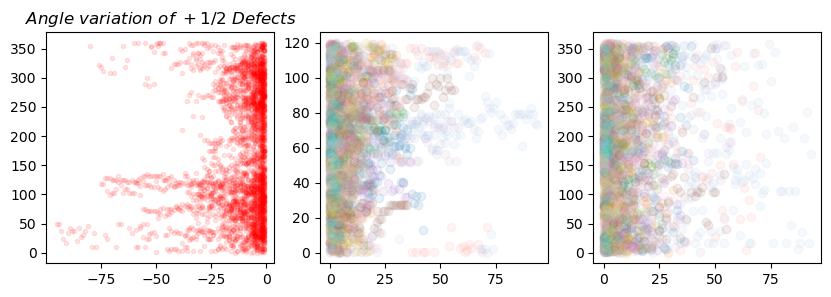

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(1,3, figsize=(10,3))
colors = plt.cm.tab20(np.linspace(0, 1, num=len(pair_stat)))
plt.set_cmap('tab20')
pangles = []
pangles_early = []
pangles_late = []
mangles = []
mpangles = []
p_vel_angles = []
p_vel_angles_rel = []
for num, angs in enumerate(pair_stat):
    # print(angs[0],angs[1])
    # ax[0].plot(np.arange(len(angs[0])), np.fmod(angs[0], 2*np.pi)*180/np.pi, "o", alpha=.1)
    # ax[1].plot(np.arange(len(angs[1])), np.fmod(angs[1], 2*np.pi)*180/np.pi, "o", alpha=.05)
    # pang = np.diff(angs[0])
    # ----------  TODO check how to --------------
    pang = angs[0] % (2*np.pi) #-angs[0][-1]
    # pang[pang<0] = pang[pang<0] + 2*np.pi
    ax[0].plot(-len(pang)+np.arange(len(pang)), (pang+np.pi % (2*np.pi))  * 180/np.pi-180, ".", color="red", alpha=.1)
    ax[1].plot(np.arange(len(angs[1][0])), angs[1][0] % (2/3*np.pi) *180/np.pi, "o", color=colors[num], alpha=.1)

    pangles.append(angs[0][:-1])
    pangles_early.append(angs[0][:-10])
    pangles_late.append(angs[0][-10:])
    mangles.append(np.concatenate(angs[1]))
    p_vel_angles.append(angs[2])
    p_vel_angles_rel.append(angs[3])

    # mpangle = np.min((angs[1] - angs[0]) %(2*np.pi), axis=0)#[-3:]
    mpangles.append(np.concatenate(angs[1] - angs[0]))

    ax[2].plot(np.arange(len(angs[2])), np.array(angs[2]) %(2*np.pi) *180/np.pi, "o", color=colors[num], alpha=.1)
    
    # if num>25:
    #     break

# plt.figure(figsize=(3,3))
# plt.hist(np.concatenate(mpangles) % (2/3*np.pi) *180/np.pi , alpha=.2, rwidth=.9)
# ax[0].set_ylim([-10,370])
# ax[1].set_ylim([-10,130])
# ax[1].set_ylim([0,120])
# ax[0].set_xlim([-1,0])
ax[0].set_title("$Angle ~variation ~of ~+1/2 ~Defects$")
# ax[0].set_ylim([-100,100])

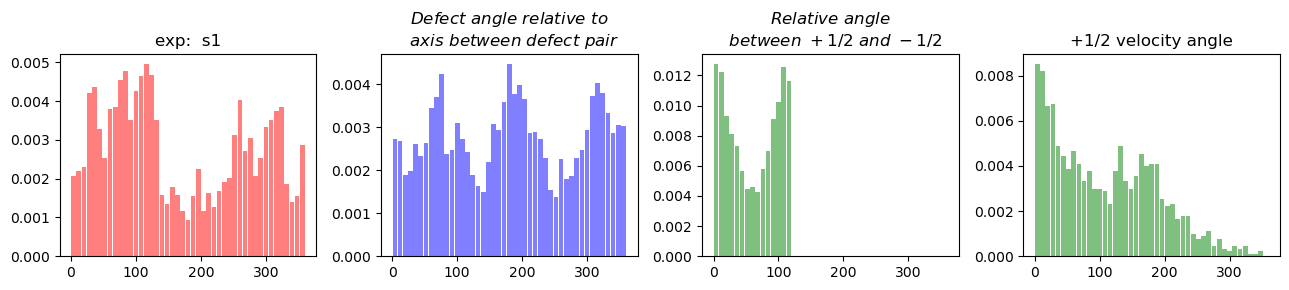

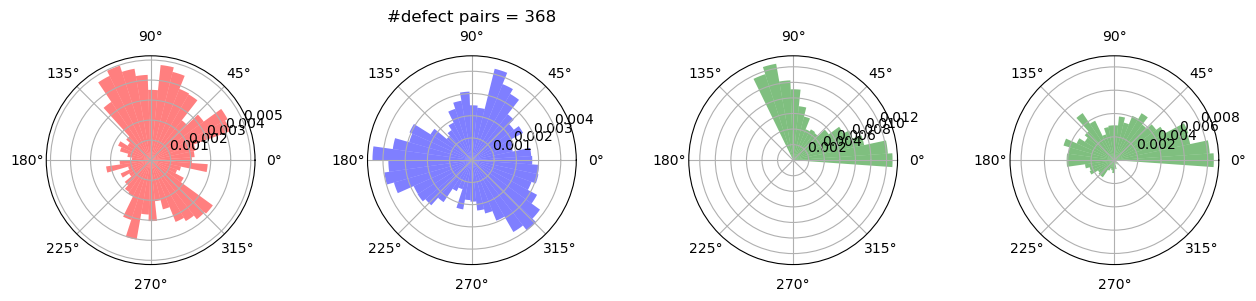

In [ ]:
%matplotlib inline
SAVE = False
bins_number = 45  # the [0, 360) interval will be subdivided into this
# number of equal bins
bins = np.linspace(0, 2*np.pi, bins_number+1)
pangle = np.concatenate(pangles) + 0 * 2*np.pi
mangle = np.concatenate(mangles) + 0 * 2/3*np.pi #2*np.pi * np.ones((1,100)).ravel() #
mpangle = np.concatenate(mpangles) + 0 * 2/3*np.pi
p_vel_angle = np.concatenate(p_vel_angles) + 0 * 2*np.pi

pangle = pangle % (2*np.pi)
mangle = mangle % (2*np.pi)
mpangle = mpangle % (2/3*np.pi)

fig1, (ax1,ax2,ax3,ax4) = plt.subplots(1, 4, figsize=(13,3))
ax1.set_title(r"exp:  " + experiment)
ax2.set_title("$Defect ~angle ~relative ~to$\n $ ~axis ~between ~defect ~pair $")
ax3.set_title("$Relative ~angle$ \n $~between ~+1/2 ~and ~-1/2$")
ax4.set_title(r"+1/2 velocity angle")
pn, _, _ =  ax1.hist(pangle*180/np.pi, bins*180/np.pi, density=True, rwidth=.9, alpha=.5, color="red")
mn, _, _ = ax2.hist(mangle*180/np.pi, bins*180/np.pi, density=True, rwidth=.9, alpha=.5, color="blue")
mpn, _, _ =  ax3.hist(mpangle*180/np.pi, bins*180/np.pi, density=True, rwidth=.9, alpha=.5, color="green")
p_vel, _, _ =  ax4.hist(p_vel_angle*180/np.pi, bins*180/np.pi, density=True, rwidth=.9, alpha=.5, color="green")
plt.tight_layout()
if SAVE:
    fig1.savefig(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_\Images/ang_distribution_hist_" + experiment +".png")


# plt.clf()
width = 2 * np.pi / bins_number
fig2, (ax1,ax2,ax3,ax4) = plt.subplots(1, 4, subplot_kw=dict(projection='polar'), figsize=(13,3))
ax1.bar(bins[:bins_number], pn, color="red",width=width, bottom=0.0, alpha=.5)
ax2.bar(bins[:bins_number], mn, color="blue",width=width, bottom=0.0, alpha=.5)
ax3.bar(bins[:bins_number], mpn, color="green",width=width, bottom=0.0, alpha=.5)
ax4.bar(bins[:bins_number], p_vel, color="green",width=width, bottom=0.0, alpha=.5)
ax2.set_title(r"#defect pairs = " + str(len(pair_stat)))
plt.tight_layout()
if SAVE:
    fig2.savefig(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_\Images/ang_distribution_polhist_" + experiment +".png")


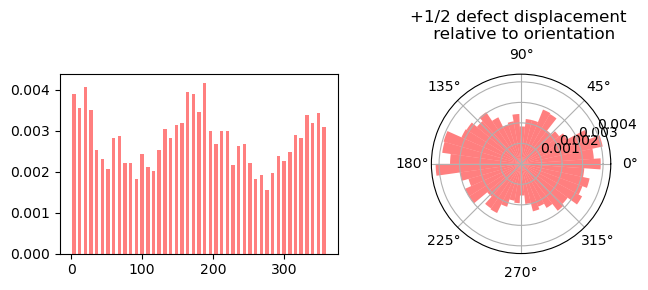

In [ ]:
fig3 = plt.figure(figsize=(7,3))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')

p_vel_angle_rel =  np.concatenate(p_vel_angles) % (2*np.pi)

n, _, _ =  ax1.hist(p_vel_angle_rel*180/np.pi, bins*180/np.pi, density=True, rwidth=.6, alpha=.5, color="red")
ax2.bar(bins[:bins_number], n, color="red",width=width, bottom=0.0, alpha=.5)
plt.title("+1/2 defect displacement \n relative to orientation")
plt.tight_layout()
if SAVE:
    fig3.savefig(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_\Images/p_direction_vs_displacement_" + experiment +".png")

Text(0.5, 1.0, 'Eary vs. Late +1/2 Defect Orienatation')

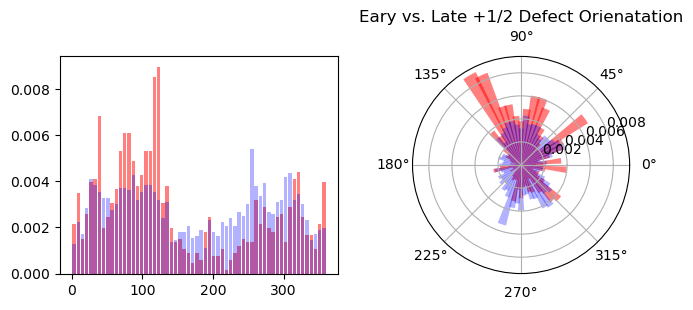

In [ ]:
fig3 = plt.figure(figsize=(7,3))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, projection='polar')
bins_number = 60
bins = np.linspace(0, 2*np.pi, bins_number+1)

pangle_early =  np.concatenate(pangles_early) % (2*np.pi)
pangle_late =  np.concatenate(pangles_late) % (2*np.pi)

n1, _, _ =  ax1.hist(pangle_early*180/np.pi, bins*180/np.pi, density=True, rwidth=.8, alpha=.5, color="red")
n2, _, _ =  ax1.hist(pangle_late*180/np.pi, bins*180/np.pi, density=True, rwidth=.8, alpha=.3, color="blue")
ax2.bar(bins[:bins_number], n1, color="red",width=width, bottom=0.0, alpha=.5)
ax2.bar(bins[:bins_number], n2, color="blue",width=width, bottom=0.0, alpha=.3)
# plt.title("+1/2 defect displacement \n relative to orientation")
plt.tight_layout()
plt.title("Eary vs. Late +1/2 Defect Orienatation")

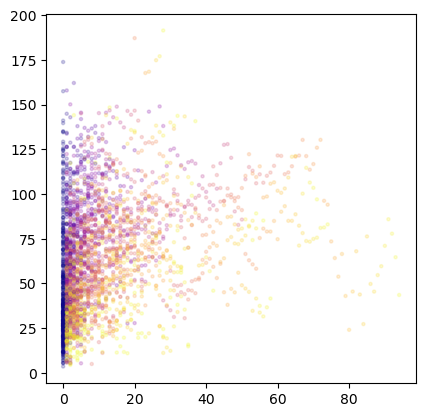

In [ ]:
mp_distance_mat = np.zeros([len(mp_distance), len(max(mp_distance, key = lambda x: len(x)))])
mp_distance_mat[:] = np.nan
for i, dist in enumerate(mp_distance):
    # print(i, j)
    plt.scatter(np.arange(len(dist)), np.flip(dist), c=np.arange(len(dist)), s=5, alpha=.2, cmap="plasma")
    # plt.plot(np.arange(len(dist)), np.flip(dist), alpha=.2)    
    mp_distance_mat[i,0:len(dist)] = np.flip(dist)
    
plt.gca().set_box_aspect(1)  

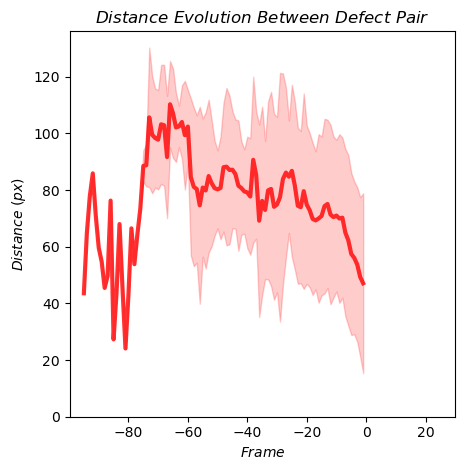

In [ ]:
%matplotlib inline
for i in range(mp_distance_mat.shape[0]):
    y = mp_distance_mat[i,:][~np.isnan(mp_distance_mat[i,:])]
    # plt.scatter(np.arange(len(y)), y, c=np.arange(len(y)), s=3, alpha=.2, cmap="plasma")


mean, stdiv = np.flip(np.nanmean(mp_distance_mat, axis=0)), np.flip(np.nanstd(mp_distance_mat, axis=0))
max_frame = mp_distance_mat.shape[1]

plt.plot(np.arange(len(mean))-max_frame, mean, "r-", alpha=.8, linewidth=3)
plt.fill_between(np.arange(len(mean))-max_frame, mean-stdiv, mean+stdiv, color="red", alpha=.2)
plt.ylim([0,None])
plt.xlim([None,30])
plt.gca().set_box_aspect(1)  
plt.xlabel('$Frame$')
plt.ylabel(r'$Distance ~(px)$') #plt.ylabel('$Distance ~(\mu m)$')
plt.title(r'$Distance ~Evolution ~Between ~Defect ~Pair$')
plt.tight_layout()
# if SAVE:
#     plt.savefig(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_\Images/defect_pair_distance_" + experiment +".png")

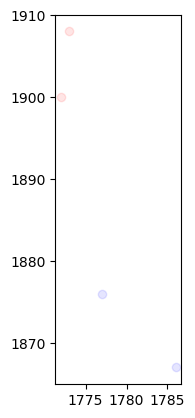

In [ ]:
plt.plot(xp, yp,"ro", alpha=.1)
plt.plot(xm, ym,"bo", alpha=.1)
plt.gca().set_aspect(1)

In [ ]:
error_var

NameError: name 'error_var' is not defined

## Flow Averaging Around Defects

In [ ]:
import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import gaussian_filter
from scipy import spatial
from sklearn.neighbors import KDTree
from scipy.stats import circmean, circstd
import os
import sys
import pandas as pd
pd.options.mode.chained_assignment = None
import seaborn as sns
import sys,time,random
import pickle 

sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

experiment = "s19"

plus_minus_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + "/PlusAndMinusTM.csv")
plus_minus_df.head()

,Unnamed: 0,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,...,CONTRAST_CH1,SNR_CH1,x_img,y_img,x_img1,y_img1,ang1,ang2,ang3,charge
0,0,ID901391,901391,26.0,81.421509,657.0,88.0,0.0,0.0,0,...,0.973672,1.625018,1293.144897,1972.526759,1293.0,1972.0,2.073451,NaN,NaN,0.5
1,1,ID901390,901390,89.0,81.421509,860.0,86.0,0.0,0.0,0,...,0.973672,1.625018,1740.161345,1977.706022,1740.0,1978.0,0.000000,NaN,NaN,0.5
2,2,ID901405,901405,124.0,74.827904,242.0,205.0,0.0,0.0,0,...,0.977139,1.318006,379.293538,1669.539881,380.0,1670.0,-1.570796,NaN,NaN,0.5
3,3,ID901404,901404,35.0,81.421509,844.0,192.0,0.0,0.0,0,...,0.973672,1.625018,1704.928521,1703.205090,1705.0,1704.0,1.319469,NaN,NaN,0.5
4,4,ID901407,901407,34.0,81.421509,718.0,220.0,0.0,0.0,0,...,0.973672,1.625018,1427.470036,1630.695409,1427.0,1632.0,-1.759292,NaN,NaN,0.5


In [76]:
minushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment + '/MinusHalf1.csv')
plushalf_df = pd.read_csv(r"C:\Users\victo\Downloads\SB_lab\RPE1_C2C12_/" + experiment +'/PlusHalf1.csv')

first_frame = minushalf_df["frame"].min()
last_frame = first_frame + plus_minus_df.FRAME.max()
# last_frame = minushalf_df["frame"].max() # Validate this number in image folders

df_plus = pd.DataFrame()
df_minus = pd.DataFrame()
df_plus[['xp', 'yp', 'angp1','FRAME']] = plus_minus_df[['x_img','y_img','ang1','FRAME']].copy()
df_minus[['xm', 'ym', 'angm1','FRAME']] = plus_minus_df[['x_img','y_img','ang1','FRAME']].copy()

In [ ]:
# TODO adjust code for experiment set

### Read Defect Positions from CSV

In [77]:
image_list_all = glob.glob(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei\*" + experiment + "*.tif")
image_list_all = natsorted(image_list_all, key=lambda y: y.lower())
image_list = image_list_all[first_frame-1:last_frame-1:1]

In [78]:
first_frame, last_frame, image_list[0], image_list[-1]

(1,
 99,
 'C:\\Users\\victo\\My Drive\\Curie\\Trinish\\30_01_18_RPE1_C2C12_5x_phase_nuclei\\RPE1_Fucci_C2C12_5x_15min_phase_nuclei_w1Trans_s14_t1.TIF',
 'C:\\Users\\victo\\My Drive\\Curie\\Trinish\\30_01_18_RPE1_C2C12_5x_phase_nuclei\\RPE1_Fucci_C2C12_5x_15min_phase_nuclei_w1Trans_s14_t98.TIF')

# Average defect ensable

### average multiple frames

In [79]:
from joblib import Parallel, delayed

box = 400

img_width = cv2.imread(image_list[0]).shape[1]
first_frame = 0
last_frame = 10#first_frame + len(image_list[first_frame:]) - 1
print(image_list[last_frame])
print("Total length: %s" % len(image_list[first_frame+1:last_frame]))

u_v_countA = Parallel(n_jobs=11)(delayed(defect_flow_frame_average)(
    # --- LEFT ----
    cv2.imread(img1)[:,:,0],cv2.imread(img2)[:,:,0], 
    df_plus[df_plus.FRAME==frame],
    defect_type="all", 
    box=(int(box),int(box)),
    filt=1
    ) for (frame,img1),img2 in zip(enumerate(image_list[first_frame:last_frame-1]),image_list[first_frame+1:last_frame]))

u_v_countB = Parallel(n_jobs=11)(delayed(defect_flow_frame_average)(
    # --- LEFT ----
    cv2.imread(img1)[:,:,0],cv2.imread(img2)[:,:,0], 
    df_minus[df_minus.FRAME==frame],
    defect_type="minus", 
    box=(int(box),int(box)),
    filt=1
    ) for (frame,img1),img2 in zip(enumerate(image_list[first_frame:last_frame-1]),image_list[first_frame+1:last_frame]))


u_ups, v_ups, count_ups = [], [], []
for q in u_v_countA:
    if q:
        u_ups.append(q[0])
        v_ups.append(q[1])
        count_ups.append(q[2])
u_ups = np.array(u_ups)
v_ups = np.array(v_ups)
count_ups = np.array(count_ups)  

u_dwns, v_dwns, count_dwns = [], [], []
for q in u_v_countB:
    if q:
        u_dwns.append(q[0])
        v_dwns.append(q[1])
        count_dwns.append(q[2])
u_dwns = np.array(u_dwns)
v_dwns = np.array(v_dwns)
count_dwns = np.array(count_dwns)


C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei\RPE1_Fucci_C2C12_5x_15min_phase_nuclei_w1Trans_s14_t11.TIF
Total length: 9


NameError: name 'df_plus' is not defined

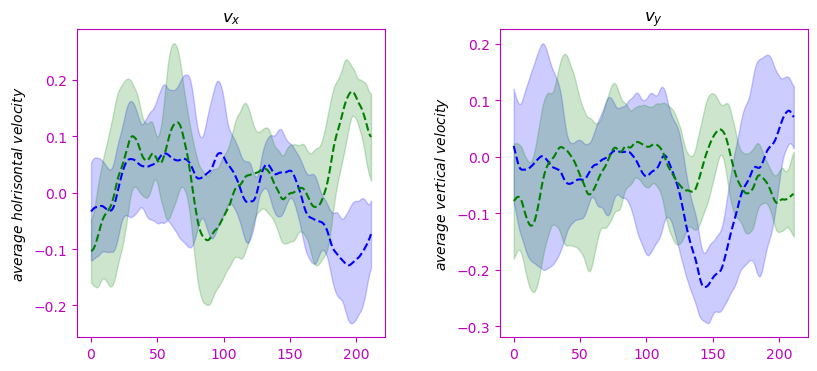

In [ ]:
def section(mat, sec_axis="x"):
    ax = 0 if sec_axis=="x" else 1
    section_av = mat.mean(axis=ax)
    section_std = mat.std(axis=ax)
    xx = np.arange(len(section_av))
    return xx, section_av, section_std


c = u_up.shape[0]//2
dc = 50

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,4))
xx, av, std  = section(u_up[:,c-dc:c+dc], sec_axis="y")
ax1.plot(xx, av, "--b")
ax1.fill_between(xx, av-std, av+std,  color="b", alpha=.2)
xx, av, std  = section(v_up[:,c-dc:c+dc], sec_axis="y")
ax2.plot(xx, av, "--b")
ax2.fill_between(xx, av-std, av+std,  color="b", alpha=.2)
ax1.set_title(r"$v_x$"); ax1.set_ylabel(r"$average ~holrisontal ~velocity$"); ax1.set_box_aspect(1)

xx, av, std  = section(u_dwn[:,c-dc:c+dc], sec_axis="y")
ax1.plot(xx, av, "--g")
ax1.fill_between(xx, av-std, av+std,  color="g", alpha=.2)
xx, av, std  = section(v_dwn[:,c-dc:c+dc], sec_axis="y")
ax2.plot(xx, av, "--g")
ax2.fill_between(xx, av-std, av+std,  color="g", alpha=.2)
ax2.set_title(r"$v_y$"); ax2.set_ylabel(r"$average ~vertical ~velocity$"); ax2.set_box_aspect(1)

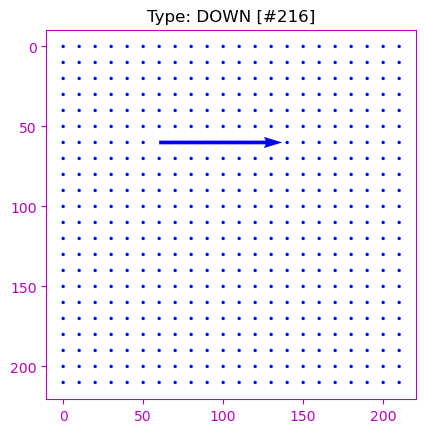

In [ ]:
a = 0* np.ones_like(u_dwn)
b = 0* np.ones_like(u_dwn)
a[step*6,step*6] = 1
plt.figure()
plt.quiver(x[::step, ::step], y[::step, ::step], 
          a[::step, ::step], -b[::step, ::step],  color='b',
          width=.01, scale=3,)
plt.gca().set_title("Type: %1s [#%1d]" % ("DOWN", np.sum(count_dwns)))
plt.gca().set_box_aspect(1) ; plt.gca().invert_yaxis()

In [ ]:
def order_parameter_sliding_win(A, a, d):
    Q = np.zeros_like(A, dtype=float)

    ii = 0
    for i in range(0, A.shape[0] - a + 1, d):
        jj = 0
        for j in range(0, A.shape[1] - a + 1, d):
            B = A[i:i + a, j:j + a]

            q = np.sqrt((np.sum(np.sum(np.cos(2 * B))) / (B.shape[0] * B.shape[1]))**2 +
                        (np.sum(np.sum(np.sin(2 * B))) / (B.shape[0] * B.shape[1]))**2)
            # q = np.sqrt((np.sum(np.sum(np.cos(2 * B))) / (B.shape[0] * B.shape[1]))**2)

            Q[i:i + a, j:j + a] = q
            jj += 1
        ii += 1

    return Q

%matplotlib qt


sigma = 30

experiment = "s10" 
image_list_all = glob.glob(r"C:\Users\victo\My Drive\Curie\Trinish\30_01_18_RPE1_C2C12_5x_phase_nuclei\*" + experiment + "*.tif")
image_list_all = natsorted(image_list_all, key=lambda y: y.lower())
image_list = image_list_all[150:250:1]

fig, ax1 = plt.subplots(1,1, figsize=(10,10))
s = 30

for im1 in image_list:
    img1 = cv2.imread(im1)[:,:,0]
    ori,_,_ = analyze_defects(img1, sigma=sigma)

    win = 10  # Size of the sliding window
    overlap = win//2   # Overlap
    op = order_parameter_sliding_win(ori, win, overlap)    

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img1)
    ax1.imshow(255-img_clahe, cmap="gray")
    
    s = 30
    y, x = np.mgrid[0:ori.shape[0], 0:ori.shape[1]] 
    plt.quiver(x[::s,::s], y[::s,::s],
        np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], 
        headaxislength=0, headwidth=0, headlength=0, width=.003, 
        color="lightgreen", scale=50, pivot='mid', alpha=.6)
    
    ax1.imshow(op, "jet", alpha=.3)
    
    break

Text(0, 0.5, '$\\langle OP \\rangle$')

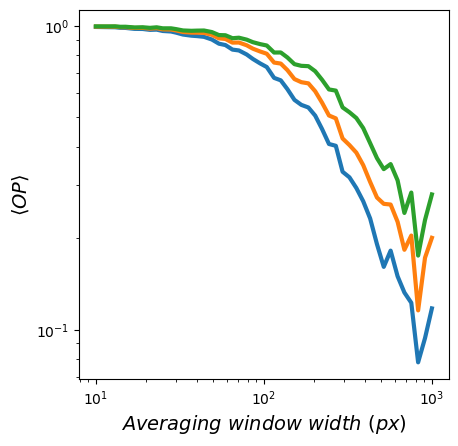

In [ ]:
%matplotlib inline

from joblib import Parallel, delayed
def mean_order_param(img, sigma, win=10, overlap=5):
    ori = analyze_defects(img1, sigma=sigma)[0]    
    return order_parameter_sliding_win(ori, win, overlap).mean()

sigmas = np.logspace(1,3,50).astype(int)
op_mean_lists = []
# op_mean_list = [(order_parameter_sliding_win(analyze_defects(img1, sigma=sigma)[0], win, overlap)).mean() for sigma in sigmas]
for im in [image_list[0], image_list[50], image_list[-1]]:
    img1 = cv2.imread(im)[:,:,0]
    op_mean_list = Parallel(n_jobs=5)(delayed(mean_order_param)(img1, 30, sigma, sigma//2) for sigma in sigmas)
    op_mean_lists.append(op_mean_list)
    plt.plot(sigmas, op_mean_list, "-", linewidth=3)
    # break

plt.gca().set_box_aspect(1)
plt.xscale('log'); plt.yscale('log')

plt.xlabel(r"$Averaging ~window ~width ~(px)$", fontsize=14)
plt.ylabel(r"$\langle OP \rangle$", fontsize=14)

In [ ]:
np.logspace(1,3,50).astype(int)

array([  10,   10,   12,   13,   14,   15,   17,   19,   21,   23,   25,
         28,   30,   33,   37,   40,   44,   49,   54,   59,   65,   71,
         79,   86,   95,  104,  115,  126,  138,  152,  167,  184,  202,
        222,  244,  268,  294,  323,  355,  390,  429,  471,  517,  568,
        625,  686,  754,  828,  910, 1000])

Text(0, 0.5, '$\\langle OP \\rangle$')

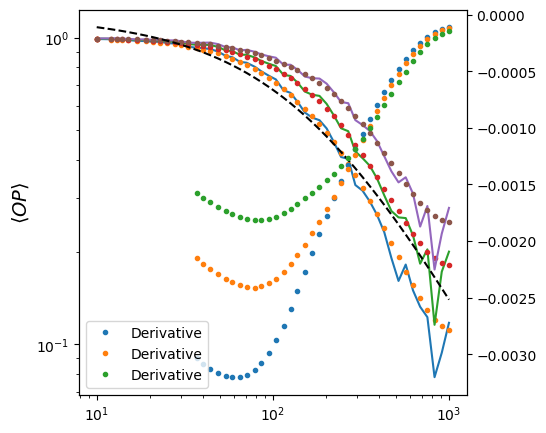

In [ ]:
%matplotlib inline
fig, ax1 = plt.subplots(1,1,  figsize=(5,5))
ax2 = ax1.twinx()

x = np.logspace(1,3,50).astype(int)
for y in op_mean_lists:
    # Smooth the data
    y1 = gaussian_filter(y, sigma=3)
    # y = (y - np.min(y)) / (np.max(y) - np.min(y))
    # Differentiate the smoothed data
    derivative = np.gradient(y1, x)
    smoothed_derivative = gaussian_filter(derivative, sigma=3)

    # Plot the original and smoothed data

    ax1.plot(x, y, label='Original Data')
    ax1.plot(x, y1, ".",label='Smoothed Data')
    ax2.plot(x, smoothed_derivative, ".", label='Derivative')

ax1.set_yscale('log')
plt.xscale('log'); 

# The curves of the order parameter can be fitted with this function a x^n/(1+(x/l)^m)
# ON x>>l and m>0, a x^(n-m), and ON x<<l and m>0, a x^(n)
y = 1.2 * x**-.02 / (1+(x/160)**1.02)
ax1.plot(x, y, "--k") 
# ax1.plot(x[:50], 10/x[:50], "--k")    
plt.legend(loc="lower left")
plt.xlabel(r"$Averaging ~window ~width ~(px)$", fontsize=14)
ax1.set_ylabel(r"$\langle OP \rangle$", fontsize=14)
